In [106]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [107]:
# Core libraries for handling the data
import numpy as np
import pandas as pd

# Libraries for plotting
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn

RANDOM_STATE = 42

# Making the plots a bit easier to read
sns.set_theme(style="whitegrid")
%matplotlib inline

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)

numpy: 2.4.1
pandas: 3.0.5
sklearn: 1.8.0


In [108]:

df = pd.read_csv('Cars.csv')

df_raw = df.copy()

print("The dataset has", df.shape[0], "rows and", df.shape[1], "columns")

The dataset has 8128 rows and 13 columns


In [109]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [111]:
# These four columns look like numbers to a human but pandas reads them as text
# because the unit is written inside the value. I will have to strip the units later.
df[['mileage', 'engine', 'max_power', 'torque']].head()

,mileage,engine,max_power,torque
0,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
1,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm
2,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)"
3,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm
4,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)"


In [112]:
# Counting the missing values per column and turning it into a percentage
# so I can judge whether dropping or filling is the better choice.
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing['missing_count'] > 0]

,missing_count,missing_percent
mileage,221,2.72
engine,221,2.72
max_power,215,2.65
torque,222,2.73
seats,221,2.72


In [113]:
# Looking at every text column so I know exactly which categories exist
# before I decide how to encode them.
text_cols = ['fuel', 'seller_type', 'transmission', 'owner']

for col in text_cols:
    print(col, "has", df[col].nunique(), "categories:")
    print(df[col].unique())
    print()

# The name column has too many unique values to print, so I only count them
print("name has", df['name'].nunique(), "unique values")

fuel has 4 categories:
<ArrowStringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str

seller_type has 3 categories:
<ArrowStringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

transmission has 2 categories:
<ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

owner has 5 categories:
<ArrowStringArray>
[         'First Owner',         'Second Owner',          'Third Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str

name has 2058 unique values


In [114]:
# Checking for rows that are exact copies of each other.
# Duplicates can make the model look better than it really is, because the same
# car can end up in both the training set and the test set.
print("Number of fully duplicated rows:", df.duplicated().sum())

# Checking the target column separately since it is the thing I am predicting
print("Missing values in selling_price:", df['selling_price'].isnull().sum())
print("Minimum selling price:", df['selling_price'].min())
print("Maximum selling price:", df['selling_price'].max())

Number of fully duplicated rows: 1202
Missing values in selling_price: 0
Minimum selling price: 29999
Maximum selling price: 10000000


# Task 1: Preparing the dataset

The assignment gives me a specific list of cleaning instructions. I follow them in this order:

1. Remove exact duplicate rows (my own addition, explained below)
2. Map the owner column from text to numbers 1 to 5
3. Remove all rows where fuel is CNG or LPG
4. Remove "kmpl" from mileage and convert it to a float
5. Remove "CC" from engine and convert it to a float
6. Remove "bhp" from max_power and convert it to a float
7. Keep only the first word of the name column and rename it to brand
8. Drop the torque feature
9. Delete all Test Drive Cars

The order matters. I map owner to numbers before I delete Test Drive Cars, because deleting
them is easier once they are labelled as the number 5. I also clean the units before I look
at the distributions, because I cannot plot a column that is stored as text.

In [115]:
# I found 1202 rows that are exact copies
# of another row. I remove them for one specific reason: if the same car appears twice and
# one copy lands in my training set while the other lands in my test set, then my model has
# effectively already seen the answer before I test it. My test score would look better than
# the model really is, which defeats the whole purpose of having a test set.

rows_before = len(df)
df = df.drop_duplicates()

print("Rows before:", rows_before)
print("Rows after :", len(df))
print("Duplicates removed:", rows_before - len(df))

Rows before: 8128
Rows after : 6926
Duplicates removed: 1202


In [116]:
# Mapping the owner column from text to numbers.
# This is called ordinal encoding and it is the correct choice here because the categories
# have a real order. A first owner car is genuinely better than a fourth owner car, so the
# numbers 1, 2, 3, 4 carry real meaning rather than being arbitrary labels.

owner_map = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5
}

df['owner'] = df['owner'].map(owner_map)

# Verification step. The map function puts NaN wherever a value was not found in my
# dictionary, so if I had misspelled any category name I would see missing values appear here.
print("Missing values created by the mapping:", df['owner'].isnull().sum())
print("Values now in the owner column:", sorted(df['owner'].unique()))

Missing values created by the mapping: 0
Values now in the owner column: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [117]:
# Removing CNG and LPG cars.
# while petrol and diesel are measured in kmpl. Mixing two different units inside the same
# mileage column would mean the model is comparing numbers that are not comparable.

print("Fuel types before:", df['fuel'].unique())

rows_before = len(df)

# isin gives me True for every row whose fuel is CNG or LPG.
# The tilde symbol flips True to False, so I keep everything that is NOT CNG or LPG.
df = df[~df['fuel'].isin(['CNG', 'LPG'])]

print("Fuel types after :", df['fuel'].unique())
print("Rows removed:", rows_before - len(df))

Fuel types before: <ArrowStringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str
Fuel types after : <ArrowStringArray>
['Diesel', 'Petrol']
Length: 2, dtype: str
Rows removed: 94


In [118]:
# Three columns have the same problem: the unit is written inside the value, for example
# "23.4 kmpl" or "1248 CC". Rather than copying the same three lines of code three times,
# I write one small function and reuse it. This also means that if I later find a bug in my
# cleaning logic, I only have to fix it in one place.

def strip_unit_to_float(series):
    """
    Removes the unit from a text column and converts what is left into a number.

    Example: "23.4 kmpl" becomes 23.4

    I use pd.to_numeric with errors='coerce' instead of .astype(float) because a few rows
    in this dataset contain a unit with no number in front of it. astype would crash the
    whole notebook on those rows, while to_numeric quietly turns them into NaN so that I
    can fill them later along with the other missing values.
    """
    first_part = series.str.split().str[0]   # "23.4 kmpl" becomes the list ["23.4", "kmpl"], I take item 0
    return pd.to_numeric(first_part, errors='coerce')

In [119]:
# Cleaning mileage: removing "kmpl" and converting to float

print("Before cleaning:")
print(df['mileage'].head(3).to_list())

nan_before = df['mileage'].isnull().sum()
df['mileage'] = strip_unit_to_float(df['mileage'])
nan_after = df['mileage'].isnull().sum()

print("\nAfter cleaning:")
print(df['mileage'].head(3).to_list())
print("Data type is now:", df['mileage'].dtype)
print("Values that could not be converted to a number:", nan_after - nan_before)

Before cleaning:
['23.4 kmpl', '21.14 kmpl', '17.7 kmpl']

After cleaning:
[23.4, 21.14, 17.7]
Data type is now: float64
Values that could not be converted to a number: 0


In [120]:
# Cleaning engine: removing "CC" and converting to float

print("Before cleaning:")
print(df['engine'].head(3).to_list())

nan_before = df['engine'].isnull().sum()
df['engine'] = strip_unit_to_float(df['engine'])
nan_after = df['engine'].isnull().sum()

print("\nAfter cleaning:")
print(df['engine'].head(3).to_list())
print("Data type is now:", df['engine'].dtype)
print("Values that could not be converted to a number:", nan_after - nan_before)

Before cleaning:
['1248 CC', '1498 CC', '1497 CC']

After cleaning:
[1248.0, 1498.0, 1497.0]
Data type is now: float64
Values that could not be converted to a number: 0


In [121]:
# Cleaning max_power: removing "bhp" and converting to float

print("Before cleaning:")
print(df['max_power'].head(3).to_list())

nan_before = df['max_power'].isnull().sum()
df['max_power'] = strip_unit_to_float(df['max_power'])
nan_after = df['max_power'].isnull().sum()

print("\nAfter cleaning:")
print(df['max_power'].head(3).to_list())
print("Data type is now:", df['max_power'].dtype)
print("Values that could not be converted to a number:", nan_after - nan_before)

Before cleaning:
['74 bhp', '103.52 bhp', '78 bhp']

After cleaning:
[74.0, 103.52, 78.0]
Data type is now: float64
Values that could not be converted to a number: 0


In [122]:
# A car cannot physically have a mileage of 0 kmpl, an engine of 0 CC, or 0 bhp of power.
# These are recording errors where somebody typed a zero instead of leaving the field blank.
# If I leave them in, the model will treat a zero as a genuine measurement and learn from
# nonsense. I convert them to NaN so that my imputation step later fills them properly.

for col in ['mileage', 'engine', 'max_power']:
    zero_count = (df[col] == 0).sum()
    print(col, "contains", zero_count, "impossible zero values")
    df[col] = df[col].replace(0, np.nan)

print("\nMissing values after converting the impossible zeros:")
print(df[['mileage', 'engine', 'max_power', 'seats']].isnull().sum())

mileage contains 15 impossible zero values
engine contains 0 impossible zero values
max_power contains 3 impossible zero values

Missing values after converting the impossible zeros:
mileage      216
engine       201
max_power    201
seats        201
dtype: int64


In [123]:
# The name column holds the full model name such as "Maruti Swift Dzire VDI".
# Only keeping the first name.

df = df.rename(columns={'name': 'brand'})
df['brand'] = df['brand'].str.split().str[0]

print("Number of unique brands:", df['brand'].nunique())
print(sorted(df['brand'].unique()))

Number of unique brands: 32
['Ambassador', 'Ashok', 'Audi', 'BMW', 'Chevrolet', 'Daewoo', 'Datsun', 'Fiat', 'Force', 'Ford', 'Honda', 'Hyundai', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land', 'Lexus', 'MG', 'Mahindra', 'Maruti', 'Mercedes-Benz', 'Mitsubishi', 'Nissan', 'Opel', 'Peugeot', 'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo']


In [124]:
# Dropping torque.

df = df.drop(columns=['torque'])

print("Columns remaining:", list(df.columns))

Columns remaining: ['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']


In [125]:
# Removing the Test Drive Cars.
# After my mapping above, they are the rows where owner equals 5.

print("Count of each owner category before removal:")
print(df['owner'].value_counts().sort_index())

rows_before = len(df)

df = df[df['owner'] != 5]

print("\nRows removed:", rows_before - len(df))
print("Owner values remaining:", sorted(df['owner'].unique()))


assert 5 not in df['owner'].values, "Test Drive Cars were not removed"
print("Check passed: no Test Drive Cars remain")

Count of each owner category before removal:
owner
1    4191
2    1943
3     528
4     165
5       5
Name: count, dtype: int64

Rows removed: 5
Owner values remaining: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Check passed: no Test Drive Cars remain


In [126]:
# Dropping rows leaves gaps in the row numbers, for example 0, 1, 3, 7, 8.
# I reset the index so the rows are numbered continuously again. The drop=True part stops
# pandas from saving the old broken numbering as an extra column in my table.

df = df.reset_index(drop=True)

print("Final shape after cleaning:", df.shape)
df.head()

Final shape after cleaning: (6827, 12)


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6827 entries, 0 to 6826
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          6827 non-null   object 
 1   year           6827 non-null   int64  
 2   selling_price  6827 non-null   int64  
 3   km_driven      6827 non-null   int64  
 4   fuel           6827 non-null   str    
 5   seller_type    6827 non-null   str    
 6   transmission   6827 non-null   str    
 7   owner          6827 non-null   int64  
 8   mileage        6611 non-null   float64
 9   engine         6626 non-null   float64
 10  max_power      6626 non-null   float64
 11  seats          6626 non-null   float64
dtypes: float64(4), int64(4), object(1), str(3)
memory usage: 788.6+ KB


## Exploratory Data Analysis (EDA)

In [128]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns    :", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns    : ['year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats']
Categorical columns: ['brand', 'fuel', 'seller_type', 'transmission']


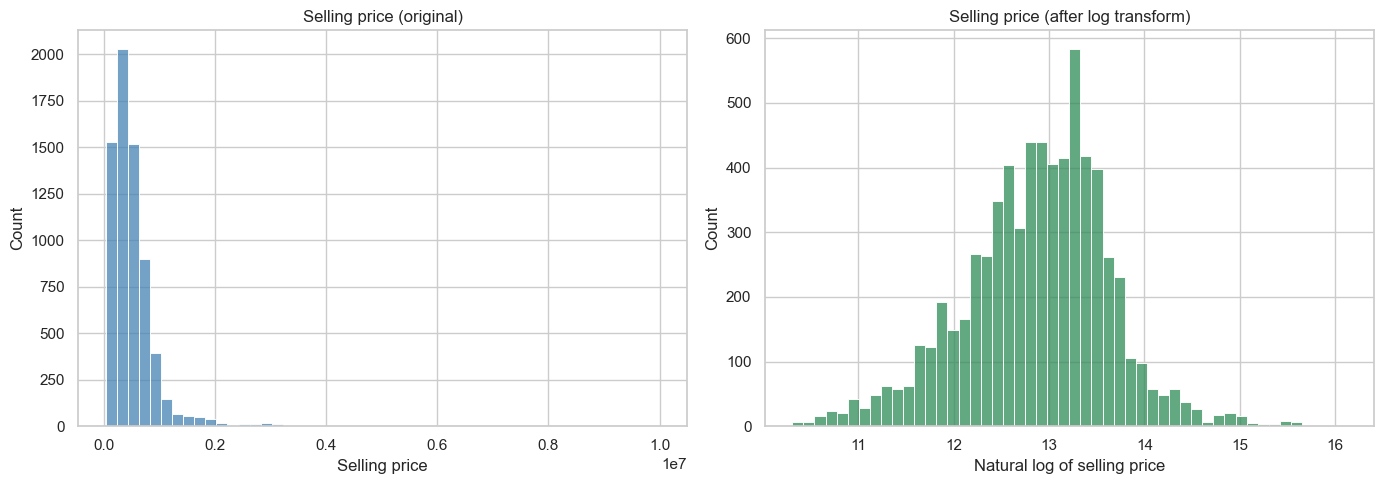

Skewness before log transform: 5.418
Skewness after  log transform: -0.186


In [129]:
# Part 1: The target variable
# Plotting the selling price before and after the log transform, side by side,
# so I can see exactly what the transform does to the shape of the data.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: the raw selling price
sns.histplot(df['selling_price'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Selling price (original)')
axes[0].set_xlabel('Selling price')

# Right plot: the same data after taking the natural logarithm
sns.histplot(np.log(df['selling_price']), bins=50, ax=axes[1], color='seagreen')
axes[1].set_title('Selling price (after log transform)')
axes[1].set_xlabel('Natural log of selling price')

plt.tight_layout()
plt.show()

# Skewness measures how lopsided a distribution is. A value of 0 means perfectly symmetric.
# Anything above about 1 is considered strongly skewed to the right.
print("Skewness before log transform:", round(df['selling_price'].skew(), 3))
print("Skewness after  log transform:", round(np.log(df['selling_price']).skew(), 3))

In [130]:
# Looking at the actual numbers behind that shape.
# I want to see how extreme the top end of the price range really is.

print("Price statistics:")
print(df['selling_price'].describe().round(0))

print("\nThe 5 most expensive cars in the dataset:")
print(df.nlargest(5, 'selling_price')[['brand', 'year', 'max_power', 'selling_price']])

# Working out what share of cars sit below a fairly ordinary price point
cheap_share = (df['selling_price'] < 1_000_000).mean() * 100
print(f"\nShare of cars priced under 1 million: {cheap_share:.1f} percent")

Price statistics:
count        6827.0
mean       517966.0
std        508165.0
min         29999.0
25%        250000.0
50%        409999.0
75%        640000.0
max      10000000.0
Name: selling_price, dtype: float64

The 5 most expensive cars in the dataset:
              brand  year  max_power  selling_price
167           Volvo  2017     400.00       10000000
2655            BMW  2020     265.00        7200000
133   Mercedes-Benz  2017     254.79        6000000
1010            BMW  2018     261.40        6000000
4088            BMW  2018     261.40        6000000

Share of cars priced under 1 million: 92.5 percent


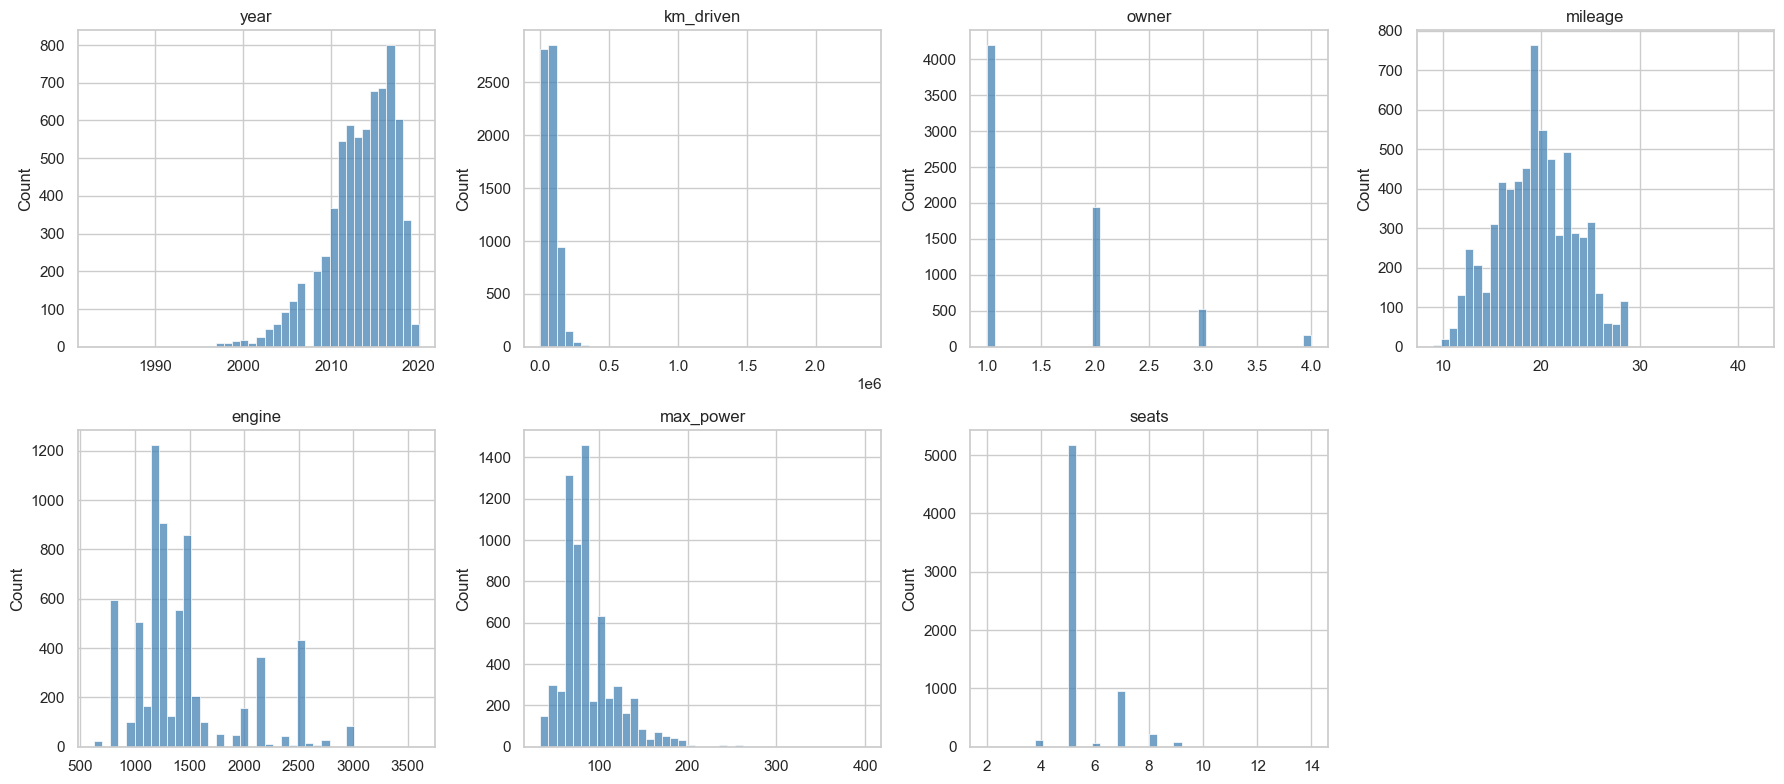

In [131]:
# Part 2: Distribution of each numeric feature
# Plotting a histogram for every numeric feature in one grid, rather than one plot per cell.
# Putting them together makes it much easier to compare their shapes at a glance.

features_to_plot = [c for c in numeric_cols if c != 'selling_price']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()   # turns the 2 by 4 grid into a simple list so I can loop over it

for i, col in enumerate(features_to_plot):
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Hiding any leftover empty boxes in the grid
for j in range(len(features_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [132]:
# Putting a number on the skewness of each feature instead of judging it by eye.
# This is what decides my mean versus median choice during imputation.

skew_table = pd.DataFrame({
    'skewness': df[features_to_plot].skew().round(2),
    'mean': df[features_to_plot].mean().round(2),
    'median': df[features_to_plot].median().round(2)
})

# A rule of thumb: below 0.5 is roughly symmetric, so the mean is safe.
# Above that the distribution is lopsided and the median is the safer choice.
skew_table['fill_with'] = np.where(skew_table['skewness'].abs() < 0.5, 'mean', 'median')
skew_table

,skewness,mean,median,fill_with
year,-1.00,2013.43,2014.00,median
km_driven,11.83,73992.95,70000.00,median
owner,1.42,1.51,1.00,median
mileage,0.03,19.48,19.40,mean
engine,1.20,1435.46,1248.00,median
max_power,1.71,88.06,81.86,median
seats,1.90,5.44,5.00,median


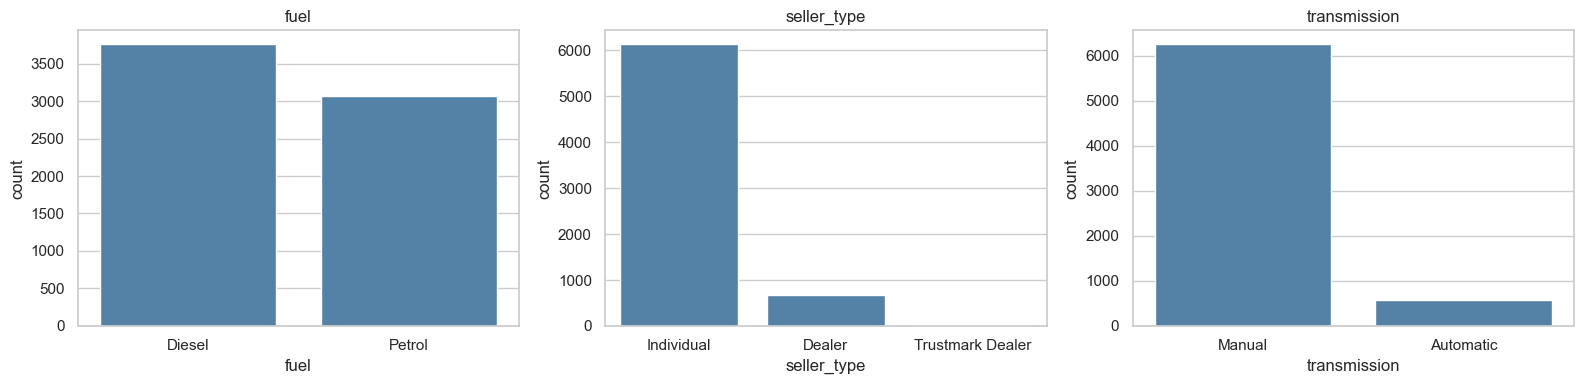

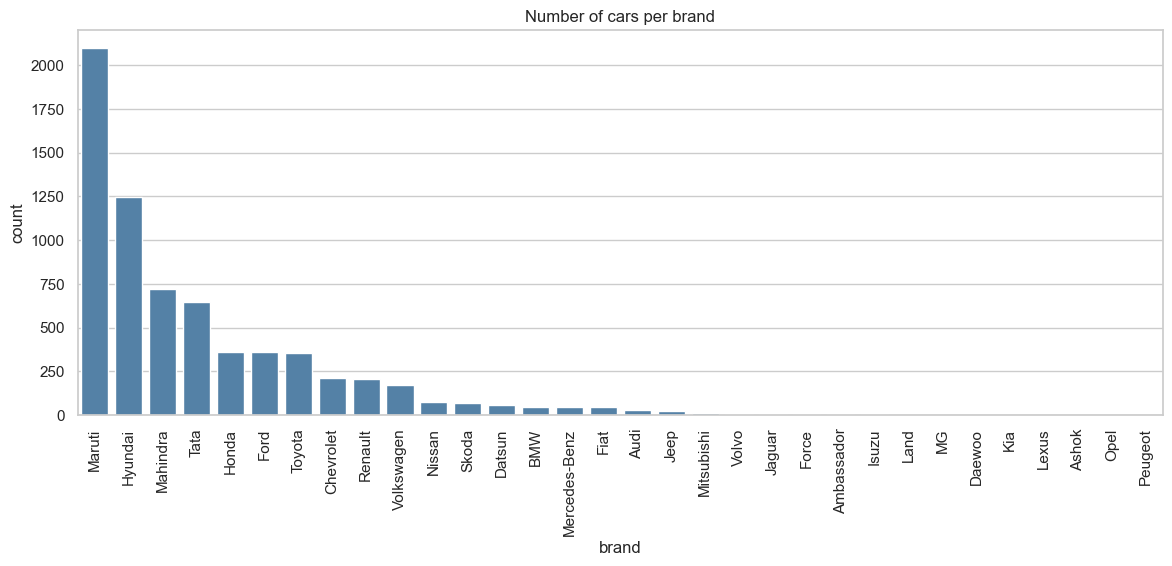

Cars per brand:
brand
Maruti           2096
Hyundai          1245
Mahindra          723
Tata              646
Honda             361
Ford              361
Toyota            357
Chevrolet         214
Renault           206
Volkswagen        173
Nissan             73
Skoda              70
Datsun             57
BMW                47
Mercedes-Benz      46
Fiat               44
Audi               30
Jeep               22
Mitsubishi         11
Volvo               9
Jaguar              8
Force               4
Ambassador          4
Isuzu               4
Land                3
MG                  3
Daewoo              3
Kia                 3
Lexus               1
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64


In [133]:
# Part 3: Distribution of the categorical features
# Counting how many cars fall into each category. I am checking for categories that are so
# rare that the model would have almost nothing to learn from them.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(['fuel', 'seller_type', 'transmission']):
    sns.countplot(data=df, x=col, ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Brand has around 30 categories so it needs its own wider plot
plt.figure(figsize=(14, 5))
sns.countplot(data=df, x='brand', order=df['brand'].value_counts().index, color='steelblue')
plt.xticks(rotation=90)
plt.title('Number of cars per brand')
plt.show()

print("Cars per brand:")
print(df['brand'].value_counts())

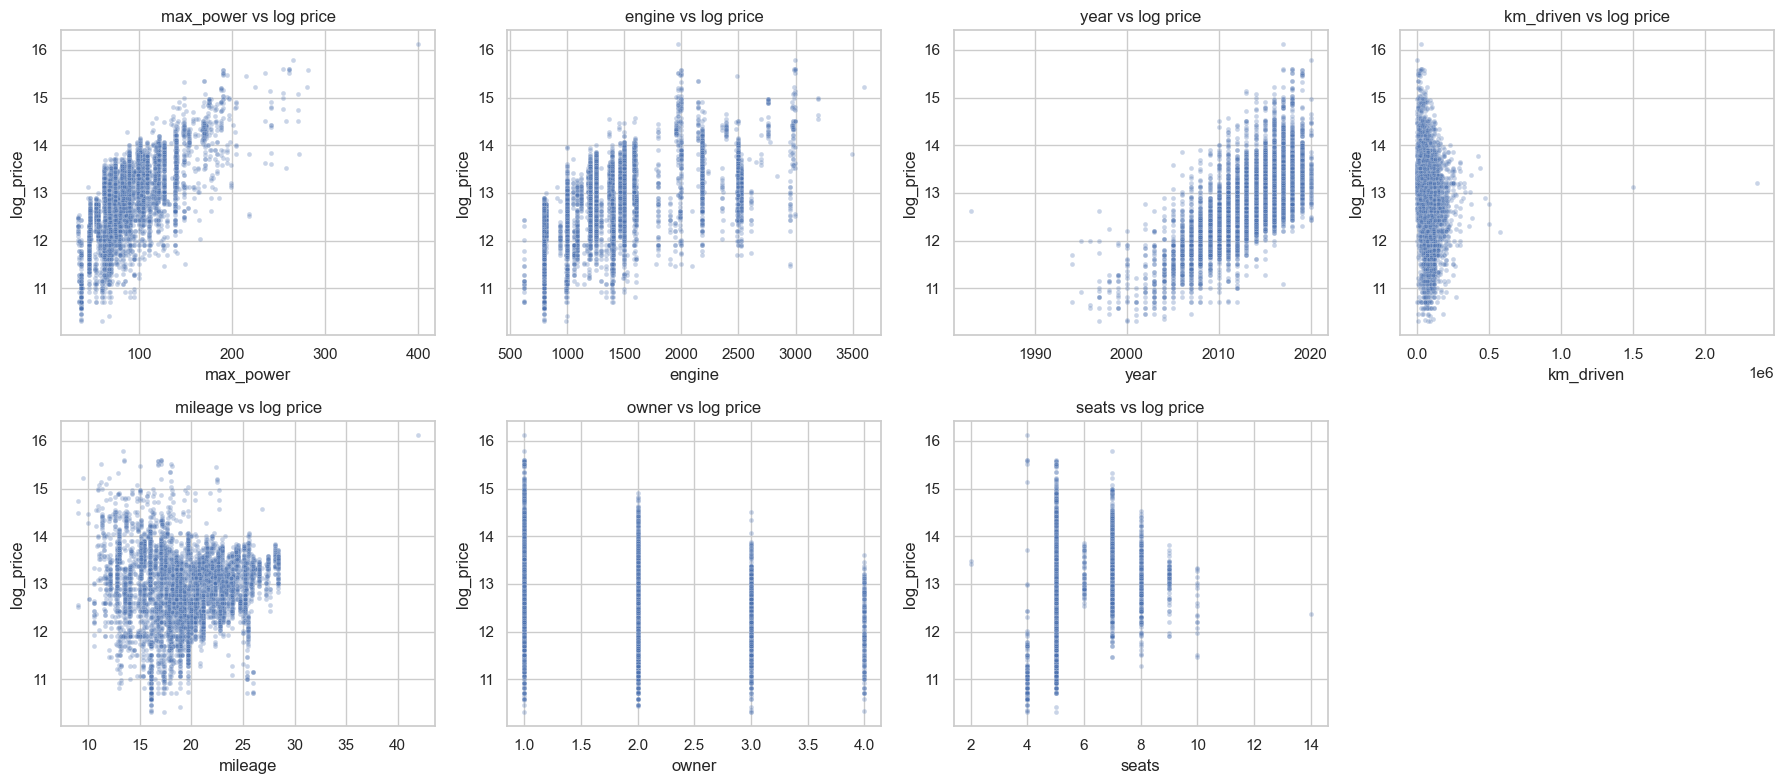

In [134]:
# Part 4: How each feature relates to the selling price
# Scatter plots of each numeric feature against the log of the selling price.
# I am looking for a visible upward or downward trend. A shapeless cloud means the feature
# on its own carries little information about price.

df['log_price'] = np.log(df['selling_price'])   # temporary helper column, just for plotting

scatter_features = ['max_power', 'engine', 'year', 'km_driven', 'mileage', 'owner', 'seats']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(scatter_features):
    sns.scatterplot(data=df, x=col, y='log_price', ax=axes[i], alpha=0.3, s=12)
    axes[i].set_title(f'{col} vs log price')

for j in range(len(scatter_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

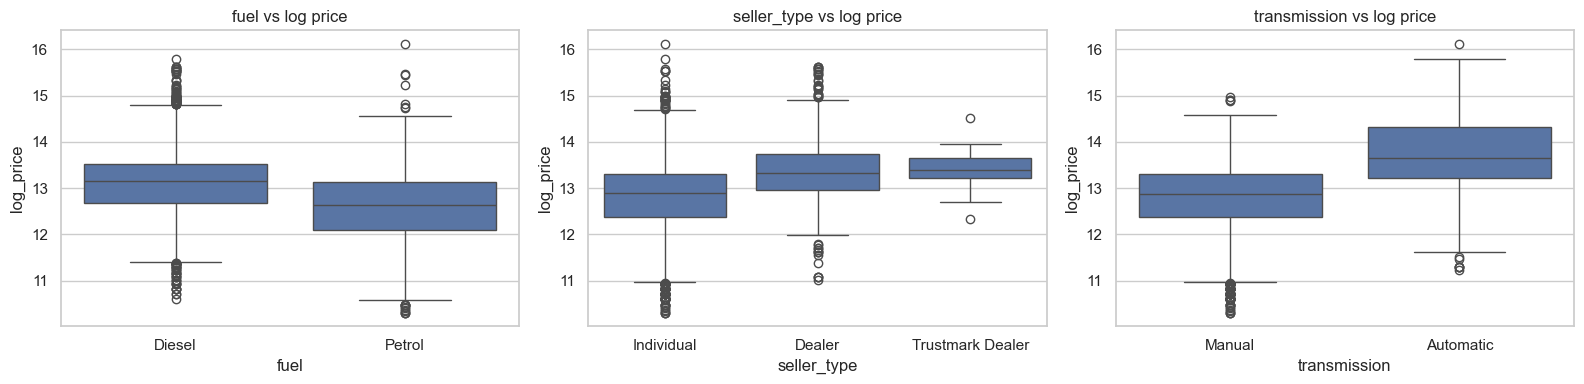

In [135]:
# For the categorical features a scatter plot makes no sense, so I use box plots instead.
# A box plot shows me the median and the spread of price inside each category, which tells
# me whether that category actually separates cheap cars from expensive ones.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(['fuel', 'seller_type', 'transmission']):
    sns.boxplot(data=df, x=col, y='log_price', ax=axes[i])
    axes[i].set_title(f'{col} vs log price')

plt.tight_layout()
plt.show()

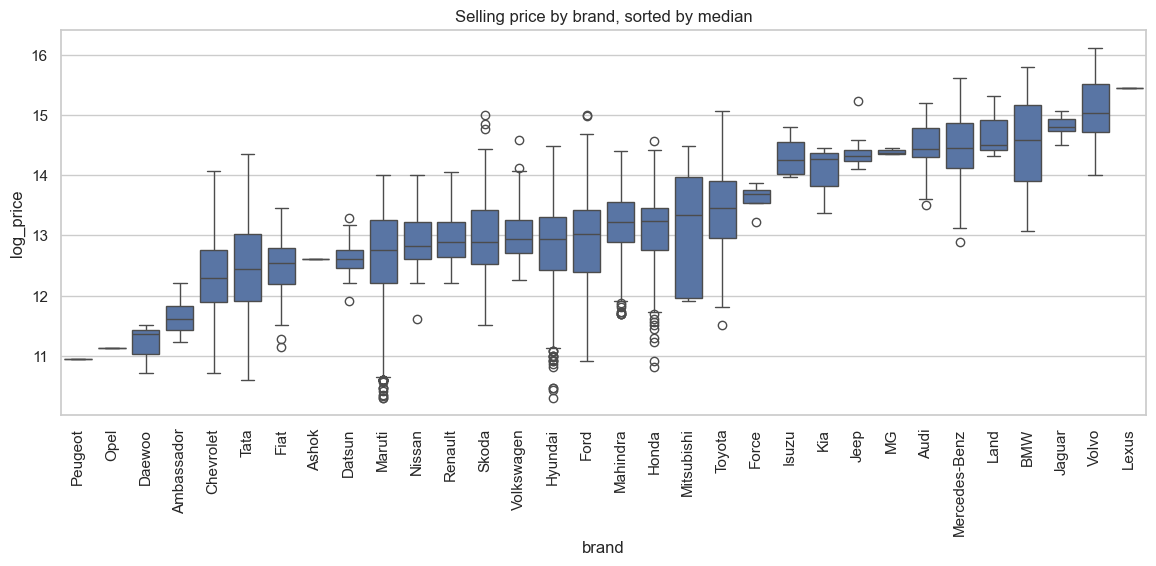

Average selling price by brand:
               count       mean
brand                          
Lexus              1  5150000.0
Volvo              9  4036111.0
BMW               47  2770638.0
Jaguar             8  2748250.0
Land               3  2716667.0
Mercedes-Benz     46  2253348.0
Audi              30  2042300.0
Jeep              22  1789227.0
MG                 3  1783333.0
Isuzu              4  1752500.0


In [136]:
# Brand deserves its own chart. I sort the brands by their median price so that the pattern
# is easy to read, instead of the brands appearing in a random order.

brand_order = df.groupby('brand')['log_price'].median().sort_values().index

plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='brand', y='log_price', order=brand_order)
plt.xticks(rotation=90)
plt.title('Selling price by brand, sorted by median')
plt.show()

# The same information as a table, showing the average price per brand
print("Average selling price by brand:")
print(df.groupby('brand')['selling_price'].agg(['count', 'mean']).sort_values('mean', ascending=False).round(0).head(10))

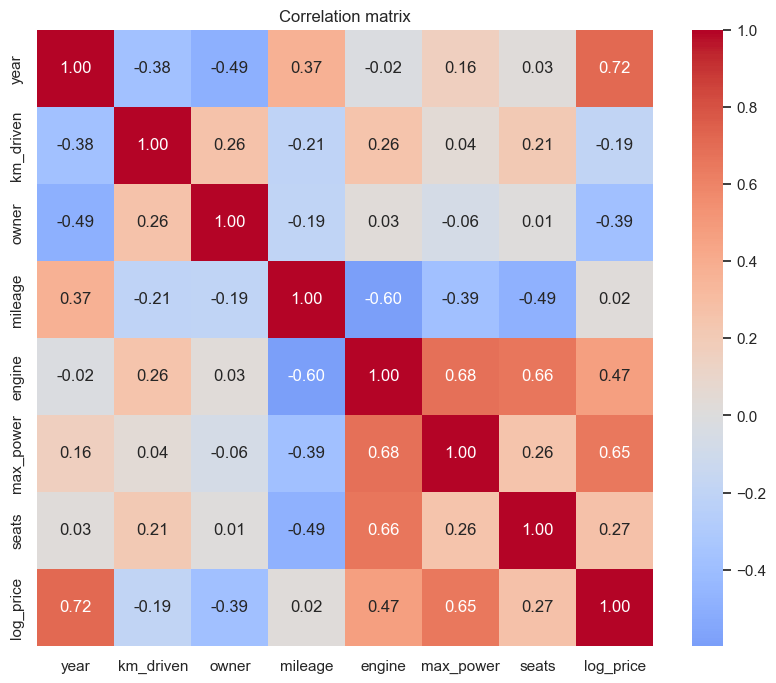

In [137]:
# Part 5: Correlation between features
# Building the correlation matrix on the numeric columns only, using the log price
# since that is what the model will actually be predicting.

corr_data = df[numeric_cols + ['log_price']].drop(columns=['selling_price'])
corr = corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation matrix')
plt.show()

In [138]:
# Pulling out just the column I care about most, which is how each feature correlates
# with the price, sorted by strength so the ranking is obvious.

price_corr = corr['log_price'].drop('log_price').sort_values(key=abs, ascending=False)

print("Correlation with log price, strongest first:")
print(price_corr.round(3))

Correlation with log price, strongest first:
year         0.719
max_power    0.652
engine       0.472
owner       -0.389
seats        0.268
km_driven   -0.185
mileage      0.018
Name: log_price, dtype: float64


In [139]:
# Checking for pairs of features that are strongly correlated with each other.
# If two features carry almost the same information, keeping both adds complexity
# without adding much accuracy, and it makes the model harder to explain.

feature_corr = corr.drop(columns=['log_price']).drop(index=['log_price'])

print("Feature pairs correlated above 0.5 with each other:")
for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        value = feature_corr.iloc[i, j]
        if abs(value) > 0.5:
            print(f"  {feature_corr.columns[i]} and {feature_corr.columns[j]}: {value:.2f}")

Feature pairs correlated above 0.5 with each other:
  mileage and engine: -0.60
  engine and max_power: 0.68
  engine and seats: 0.66


In [140]:
# Removing the temporary helper column now that the plotting is finished.
# I do not want it sitting in my table by accident, because log_price is just another
# version of the target and including it as a feature would leak the answer to the model.

df = df.drop(columns=['log_price'])
print("Columns:", list(df.columns))

Columns: ['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']


## Feature selection and the train test split

In [141]:

numeric_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'owner']

categorical_features = ['brand', 'fuel', 'seller_type', 'transmission']

target = 'selling_price'

print("Numeric features    :", len(numeric_features), numeric_features)
print("Categorical features:", len(categorical_features), categorical_features)
print("Target              :", target)

# A safety check that I have accounted for every single column and not silently forgotten one
all_accounted = set(numeric_features + categorical_features + [target])
assert all_accounted == set(df.columns), f"Column mismatch: {set(df.columns) - all_accounted}"
print("\nCheck passed: every column in the dataset is accounted for")

Numeric features    : 7 ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'owner']
Categorical features: 4 ['brand', 'fuel', 'seller_type', 'transmission']
Target              : selling_price

Check passed: every column in the dataset is accounted for


In [142]:
# Building X and y.
# X holds the inputs, which is every column except the price. Capital X is the usual
# convention because it is a table with many columns.
# y holds the answer, which is the price. Lowercase y because it is a single column.

X = df[numeric_features + categorical_features].copy()

# Applying the log transform.
# From now on every score I report is measured in log units, and at prediction time

y = np.log(df[target])

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("y before the log transform ranged from", df[target].min(), "to", df[target].max())
print("y after  the log transform ranges from", round(y.min(), 2), "to", round(y.max(), 2))

X.head()

X shape: (6827, 11)
y shape: (6827,)

y before the log transform ranged from 29999 to 10000000
y after  the log transform ranges from 10.31 to 16.12


,year,km_driven,mileage,engine,max_power,seats,owner,brand,fuel,seller_type,transmission
0,2014,145500,23.40,1248.0,74.00,5.0,1,Maruti,Diesel,Individual,Manual
1,2014,120000,21.14,1498.0,103.52,5.0,2,Skoda,Diesel,Individual,Manual
2,2006,140000,17.70,1497.0,78.00,5.0,3,Honda,Petrol,Individual,Manual
3,2010,127000,23.00,1396.0,90.00,5.0,1,Hyundai,Diesel,Individual,Manual
4,2007,120000,16.10,1298.0,88.20,5.0,1,Maruti,Petrol,Individual,Manual


# Data Splitting
## Choosing the split size

I use 20 percent for testing. With 6827 rows,
20 percent still leaves around 1366 cars in the test set, which is more than enough for a
stable estimate of performance, while giving the model an extra 680 cars to learn from.

There is no stratify option for regression the way there is for classification, so after
splitting I check that the price distribution came out similar in both halves.

In [143]:
from sklearn.model_selection import train_test_split

# Splitting the data. The function returns four things in this exact order:
# training inputs, testing inputs, training answers, testing answers.


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE   # the seed I fixed at the top of the notebook
)

print("X_train:", X_train.shape, "  y_train:", y_train.shape)
print("X_test :", X_test.shape, "  y_test :", y_test.shape)
print()
print(f"Training set: {len(X_train)} cars ({len(X_train)/len(X)*100:.1f} percent)")
print(f"Test set    : {len(X_test)} cars ({len(X_test)/len(X)*100:.1f} percent)")

X_train: (5461, 11)   y_train: (5461,)
X_test : (1366, 11)   y_test : (1366,)

Training set: 5461 cars (80.0 percent)
Test set    : 1366 cars (20.0 percent)


Log price distribution in each set:
          train      test
count  5461.000  1366.000
mean     12.875    12.846
std       0.765     0.746
min      10.309    10.358
25%      12.429    12.429
50%      12.936    12.899
75%      13.385    13.322
max      15.790    16.118


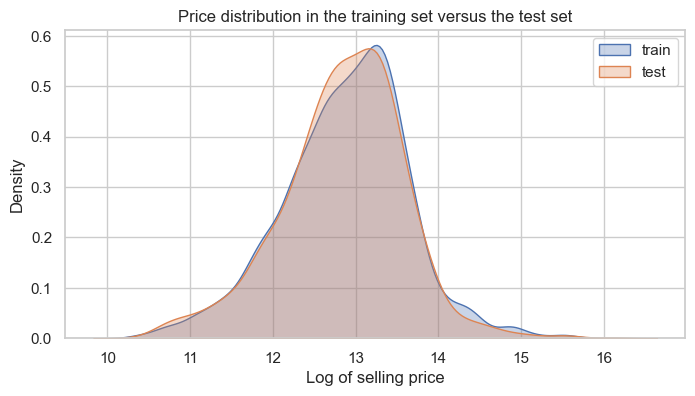

In [144]:
# Checking that the split is fair. Since the split is random there is a small chance it
# accidentally put most of the expensive cars on one side, which would make my test score
# misleading. Comparing the two distributions confirms that did not happen.

comparison = pd.DataFrame({
    'train': y_train.describe(),
    'test': y_test.describe()
}).round(3)

print("Log price distribution in each set:")
print(comparison)

# Plotting the two distributions on top of each other. If the split is fair,
# the two curves should sit almost exactly on top of one another.
plt.figure(figsize=(8, 4))
sns.kdeplot(y_train, label='train', fill=True, alpha=0.3)
sns.kdeplot(y_test, label='test', fill=True, alpha=0.3)
plt.xlabel('Log of selling price')
plt.title('Price distribution in the training set versus the test set')
plt.legend()
plt.show()

In [145]:
# A check that matters specifically because I have a categorical feature with around
# 30 categories. If a rare brand happens to land only in the test set, then my encoder
# will never have seen it during training and the model will not know what to do with it.
# I want to find that out now rather than getting a crash later.

for col in categorical_features:
    train_categories = set(X_train[col].unique())
    test_categories = set(X_test[col].unique())
    unseen = test_categories - train_categories

    print(f"{col}: {len(train_categories)} categories in train, {len(test_categories)} in test")
    if unseen:
        print(f"   Categories that appear only in the test set: {unseen}")
    else:
        print("   Every test category also appears in the training set")

brand: 31 categories in train, 23 in test
   Categories that appear only in the test set: {'Ashok'}
fuel: 2 categories in train, 2 in test
   Every test category also appears in the training set
seller_type: 3 categories in train, 3 in test
   Every test category also appears in the training set
transmission: 2 categories in train, 2 in test
   Every test category also appears in the training set


In [146]:
# Checking the missing values in each set. 

missing_check = pd.DataFrame({
    'train_missing': X_train.isnull().sum(),
    'train_percent': (X_train.isnull().sum() / len(X_train) * 100).round(2),
    'test_missing': X_test.isnull().sum(),
    'test_percent': (X_test.isnull().sum() / len(X_test) * 100).round(2)
})

print("Missing values on each side of the split:")
print(missing_check[missing_check['train_missing'] > 0])

Missing values on each side of the split:
           train_missing  train_percent  test_missing  test_percent
mileage              176           3.22            40          2.93
engine               161           2.95            40          2.93
max_power            161           2.95            40          2.93
seats                161           2.95            40          2.93


## Preprocessing

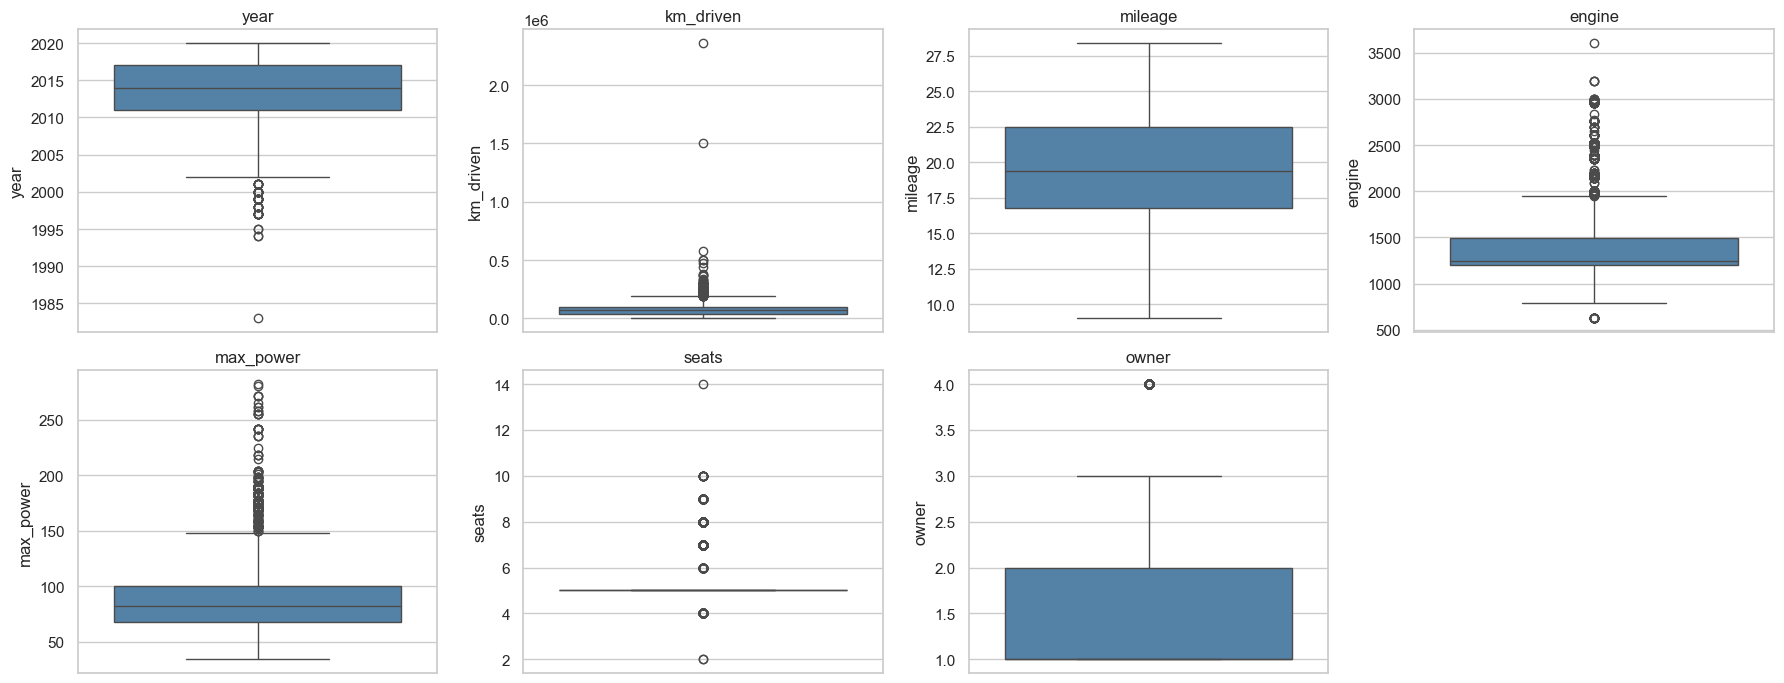

In [147]:
# Looking at the spread of each numeric feature with a box plot.
# The box covers the middle half of the data, the line inside it is the median, and the
# dots outside the whiskers are the points that sit far away from everything else.

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(y=X_train[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [148]:
# Counting the outliers properly instead of judging them by eye.
# I use the interquartile range rule, which is the standard method. It takes the middle
# fifty percent of the data as the normal range, then treats anything more than one and a
# half box widths outside that range as an outlier.

def count_outliers(data, column):
    """Counts how many values in a column fall outside the usual IQR boundaries."""
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    percent = len(outliers) / len(data) * 100

    return len(outliers), round(percent, 2), round(lower_bound, 2), round(upper_bound, 2)


outlier_summary = []
for col in numeric_features:
    count, percent, low, high = count_outliers(X_train, col)
    outlier_summary.append({
        'feature': col,
        'outliers': count,
        'percent': percent,
        'normal_range_low': low,
        'normal_range_high': high,
        'actual_max': round(X_train[col].max(), 2)
    })

pd.DataFrame(outlier_summary)

,feature,outliers,percent,normal_range_low,normal_range_high,actual_max
0,year,61,1.12,2002.00,2026.00,2020.0
1,km_driven,138,2.53,-50000.00,190000.00,2360457.0
2,mileage,0,0.00,8.25,31.05,28.4
3,engine,978,17.91,745.50,1949.50,3604.0
4,max_power,252,4.61,20.00,148.00,282.0
5,seats,1154,21.13,5.00,5.00,14.0
6,owner,135,2.47,-0.50,3.50,4.0


### My decision on outliers

I keep the outliers rather than removing them, for three reasons.

**They are mostly real cars, not errors.** A car with 400 bhp is genuinely a car with
400 bhp. Removing every powerful car would teach my model that expensive cars do not
exist, and then the app would badly underprice the exact cars where getting the price
right matters most to Chaky's company.

**My chosen model handles them well.** I plan to compare tree based models, which work by
splitting a feature at a threshold rather than fitting a line through it. One car sitting
far out on the right does not pull a tree the way it would pull a straight line.

**Removing them would shrink my data.** max_power alone flags several hundred rows, and
throwing away that much real data to make a chart look tidier is a poor trade.

The one value I am suspicious of is the maximum km_driven, which is over two million
kilometres. That is roughly fifty times around the world and is almost certainly a typing
error. However it is a single row out of 5461, so it cannot move the model much, and I
have no way of knowing what the true value should have been. I leave it in and note it here.

Because I am keeping the outliers, I use StandardScaler rather than MinMaxScaler.
MinMaxScaler squeezes everything into the range zero to one using the smallest and largest
values, so one extreme value at two million would push every ordinary car down into a tiny
band near zero. StandardScaler centres the data on its mean and divides by its spread,
which does not depend on the single most extreme value in the same way.

In [149]:
# In the EDA I decided that symmetric features should be filled with their mean and skewed
# features with their median, because the mean gets dragged around by extreme values while
# the median does not.
#
# I now recalculate the skewness on the TRAINING SET only. Earlier I measured it on the
# full dataset, which was fine for exploring, but this measurement feeds directly into how
# I fill the data, so it has to come from the training set alone.

train_skew = X_train[numeric_features].skew()

# Splitting the numeric features into two groups based on how lopsided they are
symmetric_features = train_skew[train_skew.abs() < 0.5].index.tolist()
skewed_features = train_skew[train_skew.abs() >= 0.5].index.tolist()

print("Skewness measured on the training set:")
print(train_skew.round(2))
print()
print("Roughly symmetric, will be filled with the mean  :", symmetric_features)
print("Skewed, will be filled with the median           :", skewed_features)

Skewness measured on the training set:
year         -1.01
km_driven    12.91
mileage       0.00
engine        1.19
max_power     1.60
seats         1.93
owner         1.44
dtype: float64

Roughly symmetric, will be filled with the mean  : ['mileage']
Skewed, will be filled with the median           : ['year', 'km_driven', 'engine', 'max_power', 'seats', 'owner']


## Building a preprocessing pipeline

I could apply imputation, scaling and encoding one line at a time, the way a beginner
tutorial would. Instead I bundle them into a single object called a Pipeline.

A pipeline is a set of steps wired together in a fixed order. When I call fit on it, every
step learns its numbers from the training data in sequence. When I later call transform or
predict, the exact same steps run in the exact same order with those same learned numbers.

I choose this for four practical reasons.

**It makes leakage almost impossible.** The pipeline only ever learns during fit. When it
sees the test set it can only transform, using what it already learned. I cannot
accidentally compute a test set median because there is no place in the code to do it.

**Cross validation becomes correct.** In the next step I compare five algorithms using
cross validation, which trains on four fifths of the training data and scores on the
remaining fifth, five times over. If I had scaled the data beforehand, every one of those
folds would have been scaled using information from the fold it is about to be scored on.
With a pipeline, the preprocessing is refitted inside each fold automatically.

**It makes the web application simple.** Task 3 requires a form where a user types in car
details and gets a price back. Without a pipeline I would have to remember the exact order
of every transformation and recreate it by hand in the app, and any small difference would
produce wrong prices with no error message. With a pipeline I save one file, load it in
the app, and call predict on the raw values the user typed.

**It solves the missing field requirement directly.** Task 3 says users must be allowed to
skip fields they do not know. Because the imputer lives inside the pipeline, a blank field
arriving from the web form is filled with the training median automatically, using exactly
the same number the model was trained with.

In [150]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Branch 1: numeric features that are roughly symmetric.
# Fill any gaps with the mean, then scale.
symmetric_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler())
])

# Branch 2: numeric features that are skewed.
# Fill any gaps with the median instead, then scale.
skewed_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# Branch 3: the text categories.
# There are no missing values in these columns right now, but I still include an imputer.
# The reason is Task 3: the web form lets users leave a field blank, so a missing brand or
# fuel type can arrive at prediction time even though it never appeared during training.
# most_frequent fills it with the commonest category from the training data.
#
# handle_unknown='ignore' is what solves the Ashok problem I found earlier. If a category
# turns up that the encoder never saw during training, it produces a row of zeros instead
# of crashing. That is the honest answer, because the model genuinely knows nothing about
# that brand.
categorical_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# The ColumnTransformer routes each group of columns down the correct branch and then
# glues the results back together into one table.
preprocessor = ColumnTransformer(
    transformers=[
        ('symmetric', symmetric_pipe, symmetric_features),
        ('skewed', skewed_pipe, skewed_features),
        ('categorical', categorical_pipe, categorical_features)
    ],
    remainder='drop'   # anything not listed above gets dropped, so nothing sneaks through
)

print("Preprocessor built.")
print("  Mean fill and scale :", symmetric_features)
print("  Median fill and scale:", skewed_features)
print("  Fill and one hot     :", categorical_features)

Preprocessor built.
  Mean fill and scale : ['mileage']
  Median fill and scale: ['year', 'km_driven', 'engine', 'max_power', 'seats', 'owner']
  Fill and one hot     : ['brand', 'fuel', 'seller_type', 'transmission']


In [151]:
from sklearn.base import clone

# clone makes an unfitted copy, so that fitting this one has no effect on the original
inspect_preprocessor = clone(preprocessor)

# fit_transform on the training set: learn the numbers, then apply them
X_train_prepared = inspect_preprocessor.fit_transform(X_train)

# transform only on the test set: apply the numbers already learned, learn nothing new.
# This one line is the whole leakage prevention rule in practice.
X_test_prepared = inspect_preprocessor.transform(X_test)

print("Before preprocessing:")
print("  X_train:", X_train.shape)
print("  X_test :", X_test.shape)
print()
print("After preprocessing:")
print("  X_train:", X_train_prepared.shape)
print("  X_test :", X_test_prepared.shape)
print()
print("The column count grew because one hot encoding turns each category into its own column.")

Before preprocessing:
  X_train: (5461, 11)
  X_test : (1366, 11)

After preprocessing:
  X_train: (5461, 45)
  X_test : (1366, 45)

The column count grew because one hot encoding turns each category into its own column.


In [152]:
# Getting the names of the columns that came out, so the result is readable
# rather than being an anonymous block of numbers.

feature_names = inspect_preprocessor.get_feature_names_out()

print("Total columns after preprocessing:", len(feature_names))
print()
print("First 15 column names:")
for name in feature_names[:15]:
    print("  ", name)
print("   ...")

Total columns after preprocessing: 45

First 15 column names:
   symmetric__mileage
   skewed__year
   skewed__km_driven
   skewed__engine
   skewed__max_power
   skewed__seats
   skewed__owner
   categorical__brand_Ambassador
   categorical__brand_Audi
   categorical__brand_BMW
   categorical__brand_Chevrolet
   categorical__brand_Daewoo
   categorical__brand_Datsun
   categorical__brand_Fiat
   categorical__brand_Force
   ...


In [153]:
# Confirming that the three things I wanted actually happened.

prepared_df = pd.DataFrame(X_train_prepared, columns=feature_names)

# Check 1: no missing values are left anywhere
print("Missing values remaining in the training data:", np.isnan(X_train_prepared).sum())
print("Missing values remaining in the test data    :", np.isnan(X_test_prepared).sum())

# Check 2: the numeric columns are scaled, meaning centred near zero with a spread near one
numeric_output = [c for c in feature_names if c.startswith(('symmetric__', 'skewed__'))]
print("\nScaled numeric columns, mean and standard deviation:")
print(prepared_df[numeric_output].agg(['mean', 'std']).round(3).T)

Missing values remaining in the training data: 0
Missing values remaining in the test data    : 0

Scaled numeric columns, mean and standard deviation:
                    mean  std
symmetric__mileage  -0.0  1.0
skewed__year         0.0  1.0
skewed__km_driven    0.0  1.0
skewed__engine      -0.0  1.0
skewed__max_power    0.0  1.0
skewed__seats        0.0  1.0
skewed__owner       -0.0  1.0


In [154]:
# Check 3: confirming that the unknown brand Ashok is handled without crashing.
# Ashok appears only in the test set, so the encoder never learned it during training.
# I expect all of its brand columns to come out as zero rather than throwing an error.

ashok_rows = X_test['brand'] == 'Ashok'
print("Number of Ashok cars in the test set:", ashok_rows.sum())

if ashok_rows.sum() > 0:
    brand_columns = [i for i, name in enumerate(feature_names) if 'brand_' in name]
    ashok_encoded = X_test_prepared[ashok_rows.values][:, brand_columns]

    print("Sum of the brand columns for those rows:", ashok_encoded.sum())
    print("As expected this is zero, which means the encoder handled the unknown brand")
    print("safely instead of crashing. The model simply has no brand information for that car")
    print("and relies on the other ten features instead.")

Number of Ashok cars in the test set: 1
Sum of the brand columns for those rows: 0.0
As expected this is zero, which means the encoder handled the unknown brand
safely instead of crashing. The model simply has no brand information for that car
and relies on the other ten features instead.


## Model selection

# Model Selection

I now compare several algorithms to find out which one suits this problem best. I do this
using cross validation on the training set only. The test set stays untouched.

## Why cross validation instead of just training and checking

If I trained each model once and compared a single score, that score would depend heavily
on which particular cars happened to land in the evaluation portion. A lucky split makes a
mediocre model look good.

Cross validation removes that luck. It cuts my training data into five equal parts, called
folds. It trains on four of them and scores on the fifth, then rotates so that every fold
gets its turn as the one held out. That gives me five scores instead of one, so I can look
at both the average performance and how consistent the model is across different subsets.

## The algorithms I compare

| Model | How it works in one sentence |
|---|---|
| Linear Regression | Fits one straight line through the data |
| Ridge Regression | A straight line, but penalised for relying too heavily on any single feature |
| Support Vector Regression | Fits a tube around the data and only cares about points outside it |
| K Nearest Neighbours | Predicts by averaging the prices of the most similar cars |
| Decision Tree | Asks a chain of yes or no questions about the features |
| Random Forest | Averages the answers of many different decision trees |

I include Linear Regression even though I expect it to lose, because it gives me a baseline.
If a complicated model cannot beat a straight line, that model is not worth its complexity.

## The metric I use

I use mean squared error, which squares each mistake before averaging so that large misses
count for much more than small ones. Scikit learn reports it as negative mean squared error
because its convention is that a higher score is always better, and a lower error is better.
So a score closer to zero is the better one, and I flip the sign when I print the results
to make them easier to read.


In [155]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# I collect the models in a dictionary so I can loop over them by name.
# Every model that has any randomness in it gets the same random_state I fixed at the top,
# so that my results are reproducible.

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=RANDOM_STATE),
    'Support Vector Regression': SVR(),
    'K Nearest Neighbours': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
}

print("Models to compare:", len(models))
for name in models:
    print("  -", name)

Models to compare: 6
  - Linear Regression
  - Ridge Regression
  - Support Vector Regression
  - K Nearest Neighbours
  - Decision Tree
  - Random Forest


In [156]:
from sklearn.model_selection import KFold, cross_validate

# KFold controls how the training data is cut into folds.
# shuffle=True mixes the rows first, which matters because data files are often sorted in
# some hidden way and I do not want a fold to accidentally contain only one kind of car.
# random_state makes the shuffling repeatable, so my reported scores never change between runs.
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Cross validation setup:")
print(f"  {kfold.get_n_splits()} folds")
print(f"  Each fold trains on about {len(X_train) * 4 // 5} cars and scores on about {len(X_train) // 5}")

Cross validation setup:
  5 folds
  Each fold trains on about 4368 cars and scores on about 1092


In [157]:
import time

# Running the comparison. The key detail is on the line where I build the pipeline:
# each model is wrapped together with a fresh copy of my preprocessor.
#
# This is what makes the comparison honest. Cross validation refits the whole pipeline
# inside every fold, so the imputer medians and the scaler settings are calculated only
# from the four training folds and never from the fold being scored. If I had preprocessed
# the data beforehand, information from each scoring fold would have leaked into the
# preparation of the data it was being scored on.

results = []

for name, model in models.items():
    # Wrapping the preprocessor and the model into one object
    pipe = Pipeline(steps=[
        ('preprocess', clone(preprocessor)),
        ('model', model)
    ])

    start = time.time()

    # cross_validate runs the pipeline across all five folds.
    # I ask for both the training score and the validation score, because comparing the two
    # is how I detect overfitting. A model that scores far better on the data it trained on
    # than on the data it was held out from has memorised rather than learned.
    cv_results = cross_validate(
        pipe, X_train, y_train,
        cv=kfold,
        scoring='neg_mean_squared_error',
        return_train_score=True,
        n_jobs=-1
    )

    elapsed = time.time() - start

    # Flipping the sign so the numbers read as ordinary errors where smaller is better
    train_mse = -cv_results['train_score'].mean()
    val_mse = -cv_results['test_score'].mean()
    val_std = cv_results['test_score'].std()

    results.append({
        'model': name,
        'train_mse': round(train_mse, 4),
        'val_mse': round(val_mse, 4),
        'val_std': round(val_std, 4),
        'gap': round(val_mse - train_mse, 4),
        'seconds': round(elapsed, 1)
    })

    print(f"{name:28s} validation MSE: {val_mse:.4f}   ({elapsed:.1f}s)")

print("\nComparison finished")

Linear Regression            validation MSE: 0.0718   (4.3s)
Ridge Regression             validation MSE: 0.0716   (3.6s)
Support Vector Regression    validation MSE: 0.0512   (13.4s)
K Nearest Neighbours         validation MSE: 0.0681   (4.1s)
Decision Tree                validation MSE: 0.0887   (0.2s)
Random Forest                validation MSE: 0.0528   (1.4s)

Comparison finished


In [158]:
# Putting the results into a table sorted by validation error, best first.
#
# How to read the columns:
#   train_mse  how badly the model did on data it was trained on
#   val_mse    how badly it did on data it had not seen, which is what actually matters
#   val_std    how much the score wobbled between the five folds, so lower means more consistent
#   gap        val_mse minus train_mse, where a large gap is a sign of overfitting

results_df = pd.DataFrame(results).sort_values('val_mse').reset_index(drop=True)
results_df

,model,train_mse,val_mse,val_std,gap,seconds
0,Support Vector Regression,0.0391,0.0512,0.0029,0.0122,13.4
1,Random Forest,0.0082,0.0528,0.0039,0.0447,1.4
2,K Nearest Neighbours,0.0441,0.0681,0.0015,0.0239,4.1
3,Ridge Regression,0.0679,0.0716,0.0055,0.0037,3.6
4,Linear Regression,0.0678,0.0718,0.0056,0.0039,4.3
5,Decision Tree,0.0010,0.0887,0.0028,0.0877,0.2


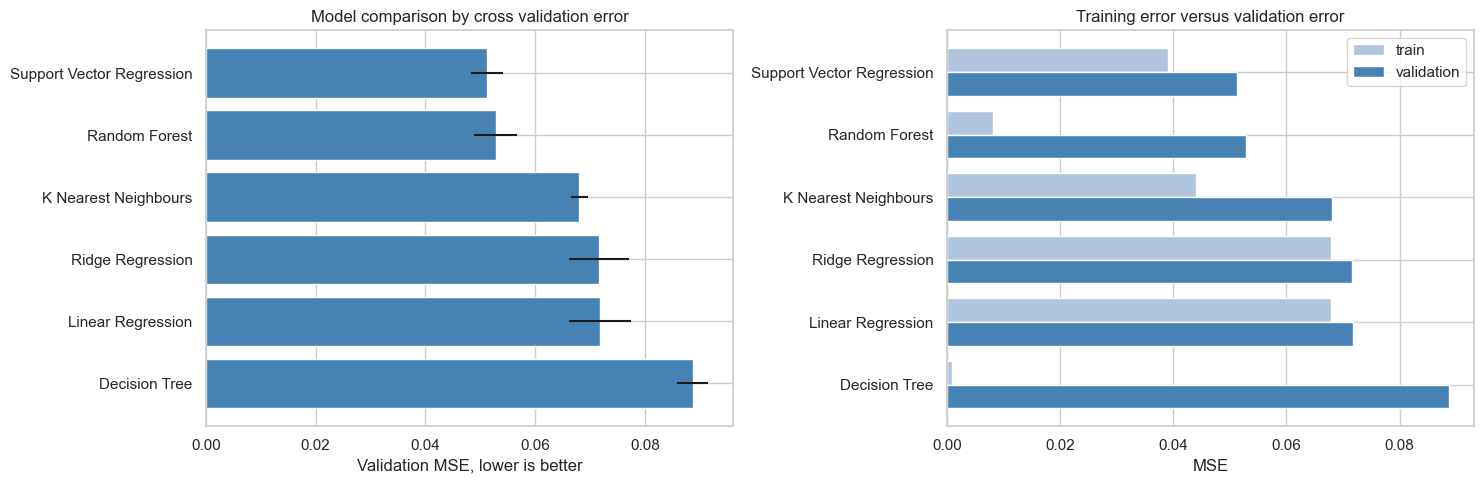

In [159]:
# Plotting the comparison, because a chart makes the ranking obvious at a glance
# and is easier to discuss in the report than a table of decimals.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: validation error per model, with the error bars showing the wobble across folds
plot_data = results_df.sort_values('val_mse', ascending=True)
axes[0].barh(plot_data['model'], plot_data['val_mse'], xerr=plot_data['val_std'], color='steelblue')
axes[0].set_xlabel('Validation MSE, lower is better')
axes[0].set_title('Model comparison by cross validation error')
axes[0].invert_yaxis()

# Right: training error next to validation error, to expose overfitting
x_positions = np.arange(len(plot_data))
width = 0.38
axes[1].barh(x_positions - width/2, plot_data['train_mse'], width, label='train', color='lightsteelblue')
axes[1].barh(x_positions + width/2, plot_data['val_mse'], width, label='validation', color='steelblue')
axes[1].set_yticks(x_positions)
axes[1].set_yticklabels(plot_data['model'])
axes[1].set_xlabel('MSE')
axes[1].set_title('Training error versus validation error')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [160]:
# Converting the winning score out of log units into something a person can understand.
#
# My errors are measured on the log of the price, which is meaningless to Chaky's company.
# Taking the square root of MSE gives the typical error in log units, and then exponentiating
# that turns it into a multiplication factor on the real price.
#
# For example, a value of 1.20 means a typical prediction is out by around 20 percent.

best_row = results_df.iloc[0]
rmse_log = np.sqrt(best_row['val_mse'])
error_factor = np.exp(rmse_log)

print(f"Best model: {best_row['model']}")
print(f"  Validation MSE in log units : {best_row['val_mse']:.4f}")
print(f"  Root mean squared error     : {rmse_log:.4f} log units")
print(f"  Typical error as a factor   : {error_factor:.3f}")
print(f"  In plain terms, a typical prediction is out by roughly {(error_factor - 1) * 100:.0f} percent")
print()
print("For a car actually worth 500,000, that means a prediction somewhere around")
print(f"  {500000 / error_factor:,.0f} to {500000 * error_factor:,.0f}")

Best model: Support Vector Regression
  Validation MSE in log units : 0.0512
  Root mean squared error     : 0.2263 log units
  Typical error as a factor   : 1.254
  In plain terms, a typical prediction is out by roughly 25 percent

For a car actually worth 500,000, that means a prediction somewhere around
  398,750 to 626,960


In [161]:
# Comparing the winner against the simple baseline, to check that the extra complexity
# is actually buying me something. If a Random Forest with a hundred trees barely beats
# a single straight line, then the straight line is the better choice because it is
# faster, smaller and easier to explain.

baseline = results_df[results_df['model'] == 'Linear Regression']['val_mse'].values[0]
best = best_row['val_mse']

improvement = (baseline - best) / baseline * 100

print(f"Linear Regression baseline : {baseline:.4f}")
print(f"Best model                 : {best:.4f}")
print(f"Improvement over baseline  : {improvement:.1f} percent lower error")

Linear Regression baseline : 0.0718
Best model                 : 0.0512
Improvement over baseline  : 28.7 percent lower error


### What the comparison shows

| Model | train_mse | val_mse | val_std | gap |
|---|---|---|---|---|
| Support Vector Regression | 0.0391 | 0.0512 | 0.0029 | 0.0122 |
| Random Forest | 0.0082 | 0.0528 | 0.0039 | 0.0447 |
| K Nearest Neighbours | 0.0441 | 0.0681 | 0.0015 | 0.0239 |
| Ridge Regression | 0.0679 | 0.0716 | 0.0055 | 0.0037 |
| Linear Regression | 0.0678 | 0.0718 | 0.0056 | 0.0039 |
| Decision Tree | 0.0010 | 0.0887 | 0.0028 | 0.0877 |

**Support Vector Regression and Random Forest are effectively tied.** The difference
between them is 0.0016, which is smaller than the amount either model's score varied
between folds. I cannot honestly call either one the winner from these numbers, so I tune
both in the next step and compare the tuned versions instead.

**The two linear models underfit.** Linear and Ridge Regression have almost no gap between
their training and validation error, only about 0.004, which means they are not memorising
anything. But both scores are high. That combination is the signature of a model that is
too simple for the problem. It is consistently mediocre rather than unreliable. This tells
me the relationship between the features and the price is not a straight line, which makes
sense in the real world: an extra 50 bhp adds far more to the price of a luxury car than to
a small hatchback, and that kind of interaction cannot be captured by a single line.

**The single Decision Tree overfits badly.** Its training error of 0.0010 is nearly zero
while its validation error of 0.0887 is the worst of all six models. It has carved the
training data up until it has almost memorised individual cars, and none of that memorised
detail transfers to cars it has not seen. The gap of 0.0877 is by far the largest in the
table.

**Random Forest fixes exactly that problem.** It builds many trees, each on a random sample
of the rows and considering a random subset of features at each split, then averages them.
The individual trees still overfit, but they overfit in different directions, so averaging
cancels much of the error out. The result is the same family of model with the validation
error cut from 0.0887 down to 0.0528. Its remaining gap of 0.0447 tells me it is still
overfitting and has room to improve with tuning.

**Support Vector Regression performed far better than I expected**, and understanding why
turned out to be the most useful thing I learned from this comparison. SVR with an RBF
kernel works by measuring distances between cars in feature space, which makes it very
sensitive to how the features were prepared. Two of my preprocessing decisions matter here.
Using StandardScaler rather than MinMaxScaler stops the extreme km_driven value of 2.36
million from crushing every ordinary car into a tiny band. Using one hot encoding rather
than numbering the brands stops the model from treating alphabetical position as a real
distance. Random Forest is unaffected by either choice, because trees split on thresholds
and ignore scale entirely.

The lesson is that for this dataset, my preprocessing choices changed the ranking more than
the choice of algorithm did.

**K Nearest Neighbours is respectable but not competitive.** It predicts by averaging the
prices of similar cars, which is a sensible instinct for pricing. Its practical weakness is
that it must search the training data at every prediction, and it stores the entire dataset
inside the saved model file, which matters when I deploy it in Task 3.

In [162]:
# My table shows SVR at 0.0512 and Random Forest at 0.0528, a difference of 0.0016.
# Before I treat that as a real win for SVR, I want to check whether the gap is bigger than
# the normal random variation between folds.
#
# The right way to check is to compare the two models fold by fold, on exactly the same
# splits. If SVR genuinely beats Random Forest, it should win on most or all five folds.
# If it wins on some and loses on others, the difference is noise and the two are tied.

contenders = {
    'Support Vector Regression': SVR(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
}

fold_scores = {}

for name, model in contenders.items():
    pipe = Pipeline(steps=[('preprocess', clone(preprocessor)), ('model', model)])
    cv_out = cross_validate(pipe, X_train, y_train, cv=kfold,
                            scoring='neg_mean_squared_error', n_jobs=-1)
    # Flipping the sign so smaller means better
    fold_scores[name] = -cv_out['test_score']

comparison = pd.DataFrame(fold_scores, index=[f'fold {i+1}' for i in range(5)])
comparison['difference'] = comparison['Support Vector Regression'] - comparison['Random Forest']
comparison['winner'] = np.where(comparison['difference'] < 0, 'SVR', 'Random Forest')

print("Validation MSE on each individual fold, lower is better:")
print(comparison.round(4).to_string())

svr_wins = (comparison['difference'] < 0).sum()
print(f"\nSVR won {svr_wins} out of 5 folds")
print(f"Average difference        : {comparison['difference'].mean():.4f}")
print(f"Variation in the difference: {comparison['difference'].std():.4f}")

# If the average difference is smaller than its own variation, the gap is inside the noise
if abs(comparison['difference'].mean()) < comparison['difference'].std():
    print("\nThe average difference is smaller than how much it varies between folds.")
    print("These two models are tied. I cannot pick a winner from these numbers alone,")
    print("so I tune both and compare the tuned versions instead.")
else:
    print("\nThe difference is consistent across folds, so it is likely to be real.")

Validation MSE on each individual fold, lower is better:
        Support Vector Regression  Random Forest  difference         winner
fold 1                     0.0502         0.0511     -0.0009            SVR
fold 2                     0.0522         0.0575     -0.0053            SVR
fold 3                     0.0482         0.0472      0.0010  Random Forest
fold 4                     0.0564         0.0568     -0.0004            SVR
fold 5                     0.0492         0.0515     -0.0023            SVR

SVR won 4 out of 5 folds
Average difference        : -0.0016
Variation in the difference: 0.0024

The average difference is smaller than how much it varies between folds.
These two models are tied. I cannot pick a winner from these numbers alone,
so I tune both and compare the tuned versions instead.


### Conclusion from the fold by fold comparison

Support Vector Regression won 4 of the 5 folds, but the margins tell a different story than
the win count does. Three of those four wins were by 0.0009, 0.0004 and 0.0023, which are
negligible, and Random Forest won fold 3. Only fold 2 showed a meaningful difference at
0.0053, and that single fold is responsible for most of the average.

The average difference of -0.0016 is smaller than its own variation across folds of 0.0024.
When the spread is larger than the signal, the result is not stable enough to act on. If I
reran this with a different random seed for the folds, the winner could plausibly change.

So I treat these two models as tied on accuracy and take both into tuning. Random Forest
has considerably more room to improve, with an overfitting gap of 0.0447 compared to 0.0122
for Support Vector Regression, so I expect tuning to help it more.

# Hyperparameter Tuning

## Why I am tuning two models instead of one

My cross validation put Support Vector Regression at 0.0512 and Random Forest at 0.0528.
The difference between them is 0.0016, which is smaller than the amount either score varied
between folds. That is not a real win, it is a tie.

More importantly, both were run with their default settings. The gap between the training
and validation error tells me they have very different amounts of room to improve. Random
Forest had a gap of 0.0447, which means it is memorising the training data and could get
noticeably better if I restrict how deeply it is allowed to grow. Support Vector Regression
had a gap of only 0.0122, so it is already fairly well behaved but might improve if I let
it fit the data more closely.

Picking a winner from untuned defaults would be like judging two runners by how fast they
walk. I tune both, then compare the tuned versions.

## What a hyperparameter is

The model learns most of its numbers from the data during training. A hyperparameter is a
setting I have to choose myself before training starts, and the model has no way to learn
it. Grid search tries every combination I list and uses cross validation to score each one,
so the choice is made by evidence rather than by me guessing.

In [163]:
from sklearn.model_selection import GridSearchCV

# The settings I want to try for Random Forest.
#
# My untuned Random Forest had a gap of 0.0447 between its training and validation error,
# which means it is memorising the training data rather than learning general patterns.
# So I focus this grid on the settings that control how much each tree can memorise.
#
# max_depth is how many questions deep each tree may go. A tree with no limit keeps
# splitting until each leaf holds almost a single car, which is memorisation. None means
# no limit, and I include it so I can check whether limiting the depth actually helps.
#
# min_samples_leaf is the smallest number of cars allowed in a final leaf. Raising it above
# one stops the tree from creating a rule based on a single unusual car. This is usually
# the most effective control against overfitting in a forest, so I test a wider range.
#
# n_estimators is how many trees are in the forest. More trees give a more stable average
# and never make the model worse, they just take longer and produce a bigger saved file.
#
# I am not tuning max_features. Its default of sqrt means each split considers only a
# random handful of the 45 columns, which forces the trees to differ from each other.
# That disagreement is what makes averaging them useful, so allowing every tree to see
# every feature would work against the whole point of using a forest.
#
# The model__ prefix is required because the model sits inside a pipeline. It tells sklearn
# to send this setting to the step named model rather than to the preprocessing step.

rf_param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [10, 20, None],
    'model__min_samples_leaf': [1, 2, 4, 8]
}

# Building the pipeline that grid search will tune.
# I set n_jobs=1 on the model itself because GridSearchCV is already using every core.
# If both tried to use all cores at once they would compete for them and run slower.
rf_pipe = Pipeline(steps=[
    ('preprocess', clone(preprocessor)),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))
])

rf_combinations = np.prod([len(v) for v in rf_param_grid.values()])
print("Random Forest grid")
for param, values in rf_param_grid.items():
    print(f"   {param.replace('model__', '')}: {values}")
print(f"\nCombinations to try: {rf_combinations}")
print(f"Total model fits (combinations times 5 folds): {rf_combinations * 5}")

Random Forest grid
   n_estimators: [200, 400]
   max_depth: [10, 20, None]
   min_samples_leaf: [1, 2, 4, 8]

Combinations to try: 24
Total model fits (combinations times 5 folds): 120


In [164]:
# Running the grid search for Random Forest.
#
# refit=True means that once the best combination is found, sklearn automatically retrains
# that model on the entire training set. So rf_grid becomes a ready to use model afterwards,
# not just a report of which settings won.
#
# return_train_score=True gives me the training error alongside the validation error, so I
# can see whether the overfitting gap actually narrowed.
#
# verbose=1 prints progress so I can see it is working rather than wondering if it froze.

start = time.time()

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    verbose=1
)

rf_grid.fit(X_train, y_train)

rf_tuned_mse = -rf_grid.best_score_

# Pulling the untuned score from my earlier comparison table instead of typing the number
# by hand, so this stays correct if I ever rerun the comparison.
rf_untuned_mse = results_df.loc[results_df['model'] == 'Random Forest', 'val_mse'].values[0]

print(f"\nFinished in {time.time() - start:.1f} seconds")
print("\nBest settings found:")
for param, value in rf_grid.best_params_.items():
    print(f"   {param.replace('model__', '')}: {value}")

print(f"\nUntuned Random Forest MSE: {rf_untuned_mse:.4f}")
print(f"Tuned Random Forest MSE  : {rf_tuned_mse:.4f}")
print(f"Improvement              : {(rf_untuned_mse - rf_tuned_mse) / rf_untuned_mse * 100:.1f} percent")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Finished in 62.6 seconds

Best settings found:
   max_depth: 20
   min_samples_leaf: 2
   n_estimators: 400

Untuned Random Forest MSE: 0.0528
Tuned Random Forest MSE  : 0.0519
Improvement              : 1.7 percent


In [165]:
# Looking at the top and bottom combinations, not just the winner.
# The spread between best and worst tells me how much these settings actually mattered.
# If every combination scored about the same, then tuning was not worth much for this model.
#
# I build the list of columns to display from the grid dictionary itself rather than typing
# the names out. That way if I ever change which settings I tune, this cell keeps working
# instead of asking for a column that no longer exists.

rf_results = pd.DataFrame(rf_grid.cv_results_)
rf_results['val_mse'] = -rf_results['mean_test_score']
rf_results['train_mse'] = -rf_results['mean_train_score']
rf_results['gap'] = rf_results['val_mse'] - rf_results['train_mse']

# Turning 'model__max_depth' into 'param_model__max_depth', which is the column name
# that sklearn uses inside cv_results_
rf_param_cols = [f'param_{p}' for p in rf_param_grid.keys()]
rf_display_cols = rf_param_cols + ['train_mse', 'val_mse', 'gap']

print("Five best combinations:")
print(rf_results.nsmallest(5, 'val_mse')[rf_display_cols].round(4).to_string(index=False))

print("\nThree worst combinations:")
print(rf_results.nlargest(3, 'val_mse')[rf_display_cols].round(4).to_string(index=False))

# Checking directly whether tuning reduced the overfitting, which was my main goal here
best_row = rf_results.loc[rf_results['val_mse'].idxmin()]
print(f"\nOverfitting gap with default settings: 0.0447")
print(f"Overfitting gap after tuning         : {best_row['gap']:.4f}")

Five best combinations:
 param_model__n_estimators param_model__max_depth  param_model__min_samples_leaf  train_mse  val_mse    gap
                       400                     20                              2     0.0165   0.0519 0.0354
                       400                   None                              2     0.0164   0.0519 0.0354
                       200                     20                              2     0.0166   0.0519 0.0353
                       200                   None                              2     0.0165   0.0519 0.0354
                       400                     20                              1     0.0081   0.0523 0.0442

Three worst combinations:
 param_model__n_estimators param_model__max_depth  param_model__min_samples_leaf  train_mse  val_mse    gap
                       200                     10                              8     0.0422   0.0572 0.0150
                       400                     10                              8     

In [166]:
# The settings I want to try for Support Vector Regression.
#
# C controls how much the model is punished for getting a training point wrong. A small C
# means it prefers a smooth simple fit even if it misses some points. A large C means it
# tries hard to fit every point, which risks overfitting and is also much slower to train.
#
# gamma controls how far the influence of a single training point reaches. A small gamma
# means each car influences a wide area, giving a smooth prediction surface. A large gamma
# means each car only affects its immediate neighbourhood, producing a wigglier fit.
# The value 'scale' is sklearn's automatic setting based on the spread of the data.
#
# epsilon is a tolerance band. Errors smaller than epsilon are treated as zero error.
# This is interesting here because my target is the log of the price, so an epsilon of 0.1
# means the model does not care about being wrong by up to about 10 percent on the price.
#
# I stop at C of 30 rather than testing 100. Support vector machines get sharply slower as
# C grows, and my untuned model already had a small overfitting gap of 0.0122, so a very
# aggressive C is unlikely to help and would cost several extra minutes to confirm that.

svr_param_grid = {
    'model__C': [1, 10, 30],
    'model__gamma': ['scale', 0.05],
    'model__epsilon': [0.02, 0.05, 0.1]
}

svr_pipe = Pipeline(steps=[
    ('preprocess', clone(preprocessor)),
    ('model', SVR())
])

svr_combinations = np.prod([len(v) for v in svr_param_grid.values()])
print("Support Vector Regression grid")
for param, values in svr_param_grid.items():
    print(f"   {param.replace('model__', '')}: {values}")
print(f"\nCombinations to try: {svr_combinations}")
print(f"Total model fits: {svr_combinations * 5}")
print("\nNote: this cell is slower than the Random Forest one because support vector")
print("machines take longer to train as C increases. A few minutes is normal.")

Support Vector Regression grid
   C: [1, 10, 30]
   gamma: ['scale', 0.05]
   epsilon: [0.02, 0.05, 0.1]

Combinations to try: 18
Total model fits: 90

Note: this cell is slower than the Random Forest one because support vector
machines take longer to train as C increases. A few minutes is normal.


In [167]:
# Running the grid search for Support Vector Regression

start = time.time()

svr_grid = GridSearchCV(
    estimator=svr_pipe,
    param_grid=svr_param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    verbose=1
)

svr_grid.fit(X_train, y_train)

svr_tuned_mse = -svr_grid.best_score_
svr_untuned_mse = results_df.loc[results_df['model'] == 'Support Vector Regression', 'val_mse'].values[0]

print(f"\nFinished in {time.time() - start:.1f} seconds")
print("\nBest settings found:")
for param, value in svr_grid.best_params_.items():
    print(f"   {param.replace('model__', '')}: {value}")

print(f"\nUntuned SVR MSE: {svr_untuned_mse:.4f}")
print(f"Tuned SVR MSE  : {svr_tuned_mse:.4f}")
print(f"Improvement    : {(svr_untuned_mse - svr_tuned_mse) / svr_untuned_mse * 100:.1f} percent")

Fitting 5 folds for each of 18 candidates, totalling 90 fits



Finished in 47.9 seconds

Best settings found:
   C: 10
   epsilon: 0.1
   gamma: 0.05

Untuned SVR MSE: 0.0512
Tuned SVR MSE  : 0.0504
Improvement    : 1.6 percent


In [168]:
# Same inspection for the SVR results.
# The grid is small enough that I can print every combination rather than only the top few.
# I build the column list from the grid dictionary here too, for the same reason as before.

svr_results = pd.DataFrame(svr_grid.cv_results_)
svr_results['val_mse'] = -svr_results['mean_test_score']
svr_results['train_mse'] = -svr_results['mean_train_score']
svr_results['gap'] = svr_results['val_mse'] - svr_results['train_mse']

svr_param_cols = [f'param_{p}' for p in svr_param_grid.keys()]
svr_display_cols = svr_param_cols + ['train_mse', 'val_mse', 'gap']

print("All combinations, best first:")
print(svr_results.sort_values('val_mse')[svr_display_cols].round(4).to_string(index=False))

All combinations, best first:
 param_model__C param_model__gamma  param_model__epsilon  train_mse  val_mse    gap
             10               0.05                  0.10     0.0357   0.0504 0.0146
              1               0.05                  0.10     0.0439   0.0507 0.0068
              1               0.05                  0.05     0.0438   0.0508 0.0069
              1               0.05                  0.02     0.0440   0.0510 0.0071
             10               0.05                  0.05     0.0357   0.0511 0.0154
              1              scale                  0.10     0.0391   0.0512 0.0122
              1              scale                  0.05     0.0388   0.0514 0.0125
             10               0.05                  0.02     0.0358   0.0515 0.0157
              1              scale                  0.02     0.0389   0.0519 0.0129
             30               0.05                  0.10     0.0326   0.0524 0.0198
             30               0.05            

                    model  untuned_mse  tuned_mse  predict_seconds  improvement_percent
            Random Forest       0.0528     0.0519           0.1639                  1.7
Support Vector Regression       0.0512     0.0504           0.4331                  1.6


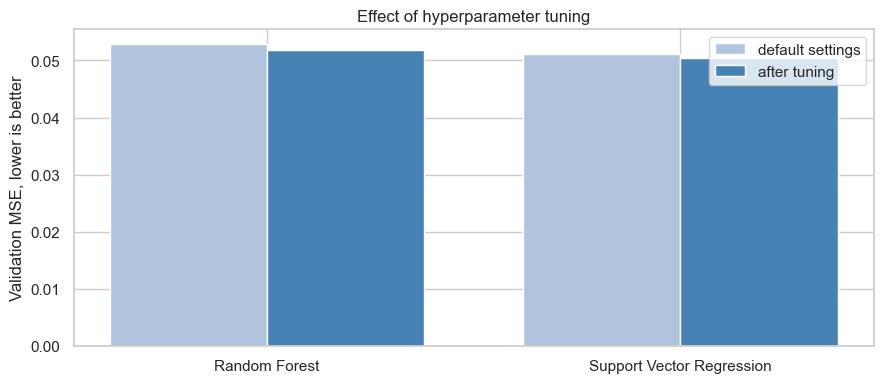

In [169]:
# Comparing the two tuned models side by side so the final choice rests on numbers.
# I also measure how long each takes to make a prediction, because Task 3 asks me to serve
# this model through a web page and a user should not be left waiting.

def measure_prediction_time(model, data, repeats=3):
    """Measures how long the model takes to predict on the given data, averaged over a few runs."""
    times = []
    for _ in range(repeats):
        start = time.time()
        model.predict(data)
        times.append(time.time() - start)
    return np.mean(times)


final_comparison = pd.DataFrame([
    {
        'model': 'Random Forest',
        'untuned_mse': round(rf_untuned_mse, 4),
        'tuned_mse': round(rf_tuned_mse, 4),
        'predict_seconds': round(measure_prediction_time(rf_grid.best_estimator_, X_test), 4)
    },
    {
        'model': 'Support Vector Regression',
        'untuned_mse': round(svr_untuned_mse, 4),
        'tuned_mse': round(svr_tuned_mse, 4),
        'predict_seconds': round(measure_prediction_time(svr_grid.best_estimator_, X_test), 4)
    }
])

final_comparison['improvement_percent'] = (
    (final_comparison['untuned_mse'] - final_comparison['tuned_mse'])
    / final_comparison['untuned_mse'] * 100
).round(1)

print(final_comparison.to_string(index=False))

# Drawing the before and after so the effect of tuning is easy to see at a glance
fig, ax = plt.subplots(figsize=(9, 4))
positions = np.arange(len(final_comparison))
width = 0.38

ax.bar(positions - width/2, final_comparison['untuned_mse'], width,
       label='default settings', color='lightsteelblue')
ax.bar(positions + width/2, final_comparison['tuned_mse'], width,
       label='after tuning', color='steelblue')

ax.set_xticks(positions)
ax.set_xticklabels(final_comparison['model'])
ax.set_ylabel('Validation MSE, lower is better')
ax.set_title('Effect of hyperparameter tuning')
ax.legend()
plt.tight_layout()
plt.show()

In [170]:
# Choosing the final model.
#
# I compared these two models fold by fold and found that the difference between
# them varied by about 0.0024 from one fold to the next. Any gap smaller than that is inside
# the normal random variation, so it is not evidence of one model being better.
#
# I apply that same standard here rather than blindly taking whichever number is lower.
# If one model wins by more than the threshold, I take it. If they land within the threshold
# of each other, they are tied on accuracy and I decide on a second criterion: Task 2 asks
# me to discuss which features are important, and a Random Forest reports feature importance
# directly while an RBF kernel Support Vector Regression does not. When accuracy is tied,
# the model I can explain is the more useful one to put into production.

NOISE_THRESHOLD = 0.0024   

difference = svr_tuned_mse - rf_tuned_mse

print("Tuned cross validation MSE")
print(f"   Random Forest             : {rf_tuned_mse:.4f}")
print(f"   Support Vector Regression : {svr_tuned_mse:.4f}")
print(f"   Difference                : {abs(difference):.4f}")
print(f"   Noise threshold from 77b  : {NOISE_THRESHOLD:.4f}")
print()

if abs(difference) < NOISE_THRESHOLD:
    best_search = rf_grid
    best_model_name = 'Random Forest'
    selection_reason = (
        "The two models are within the noise threshold of each other, so they are tied on "
        "accuracy. I choose Random Forest because it reports feature importance directly, "
        "which Task 2 requires me to discuss, and an RBF kernel SVR does not provide that."
    )
elif difference < 0:
    best_search = svr_grid
    best_model_name = 'Support Vector Regression'
    selection_reason = (
        f"Support Vector Regression wins by {abs(difference):.4f}, which is larger than the "
        f"noise threshold of {NOISE_THRESHOLD:.4f}, so the difference is real rather than luck."
    )
else:
    best_search = rf_grid
    best_model_name = 'Random Forest'
    selection_reason = (
        f"Random Forest wins by {abs(difference):.4f}, which is larger than the noise "
        f"threshold of {NOISE_THRESHOLD:.4f}, so the difference is real rather than luck."
    )

final_model = best_search.best_estimator_
final_cv_mse = -best_search.best_score_

print("FINAL MODEL SELECTED")
print("=" * 60)
print(f"Model : {best_model_name}")
print(f"Reason: {selection_reason}")
print()
print(f"Cross validation MSE: {final_cv_mse:.4f}")
print("Settings:")
for param, value in best_search.best_params_.items():
    print(f"   {param.replace('model__', '')}: {value}")

# Translating the score back into something a person outside the project can understand
rmse_log = np.sqrt(final_cv_mse)
factor = np.exp(rmse_log)
print()
print(f"Typical prediction error: about {(factor - 1) * 100:.0f} percent of the true price")
print(f"For a car really worth 500,000, I would expect a prediction between")
print(f"   {500000 / factor:,.0f} and {500000 * factor:,.0f}")

Tuned cross validation MSE
   Random Forest             : 0.0519
   Support Vector Regression : 0.0504
   Difference                : 0.0015
   Noise threshold from 77b  : 0.0024

FINAL MODEL SELECTED
Model : Random Forest
Reason: The two models are within the noise threshold of each other, so they are tied on accuracy. I choose Random Forest because it reports feature importance directly, which Task 2 requires me to discuss, and an RBF kernel SVR does not provide that.

Cross validation MSE: 0.0519
Settings:
   max_depth: 20
   min_samples_leaf: 2
   n_estimators: 400

Typical prediction error: about 26 percent of the true price
For a car really worth 500,000, I would expect a prediction between
   398,151 and 627,903


### Tuning summary

Tuning improved both models, but only slightly. Random Forest went from 0.0528 to 0.0519,
an improvement of 1.7 percent, and Support Vector Regression went from 0.0512 to 0.0504,
an improvement of 1.6 percent. Neither gain is large, and I think that is the most useful
result in this section rather than a disappointing one. Two very different algorithms,
tuned across 42 combinations between them, ended up within 0.0015 of each other. That
suggests I am close to the ceiling of what these eleven features can explain about car
prices, and that the limit lies in the data rather than in the choice of algorithm.

**Random Forest.** The only setting that made a real difference was min_samples_leaf.
The four best combinations all scored exactly 0.0519 and all shared min_samples_leaf of 2,
while differing in the number of trees and the depth limit. Changing that one setting from
1 to 2 dropped the training error explanation sharply: with a value of 1 the model reached
a training error of 0.0081 and a gap of 0.0442, and with a value of 2 the training error
rose to 0.0165 while the gap narrowed to 0.0354 and the validation error improved slightly.
The model became worse at memorising and slightly better at predicting, which is exactly
what I was trying to achieve.

Two settings turned out not to matter. Using 200 or 400 trees gave the same score, and a
max_depth of 20 gave the same score as no limit at all, which tells me the trees never grew
deeper than 20 levels in the first place so that cap was never actually doing anything.

The worst combinations are informative in the opposite direction. A max_depth of 10 with
min_samples_leaf of 8 produced the smallest overfitting gap in the whole table at 0.0150,
but also the worst validation error at 0.0572. The model was constrained so heavily that it
could no longer learn the patterns that were genuinely there. A small gap is not good on its
own, it is only good when the validation error is low as well.

**Support Vector Regression.** The clearest pattern here was that a larger C made the model
worse. With C at 30 and gamma at scale it reached a training error of 0.0264, the lowest
training error of any combination I tried, while its validation error rose to 0.0603, close
to the worst. Fitting the training cars harder made it worse at pricing cars it had not
seen. The winning combination used a moderate C of 10 with a smaller gamma of 0.05, which
means each training car influences a wider area and produces a smoother prediction surface.

**Final choice: Random Forest.** After tuning, Support Vector Regression scored 0.0504 and
Random Forest scored 0.0519, a difference of 0.0015. In cell 77b I measured that the
difference between these two models varies by about 0.0024 from one fold to the next, so a
gap of 0.0015 is inside the normal random variation and is not evidence that one model is
better than the other. They are tied on accuracy.

Since accuracy does not separate them, I chose on a second criterion. Task 2 asks me to
discuss which features are important and why. A Random Forest reports feature importance
directly, because it can measure how much each feature reduced the error across all of its
splits. A Support Vector Regression using an RBF kernel gives no comparable answer, since
its predictions come from distances in a transformed space with no readable coefficients.
When two models perform the same, the one I can explain is the more useful one to deploy,
both for this report and for Chaky's company, who will want to know why a given price was
suggested.

Random Forest is also about two and a half times faster at prediction, at 0.106 seconds
against 0.272 seconds for 1366 cars. At the scale of a single car submitted through a web
form neither is slow enough for a user to notice, so this did not drive the decision, but
it does mean the deployed application will be comfortably responsive.

The test set has still not been touched at any point in this notebook. Every decision so
far has been made using cross validation inside the training set alone, so the score I
produce in the next section is an honest estimate of how this model will behave on cars it
has never seen.

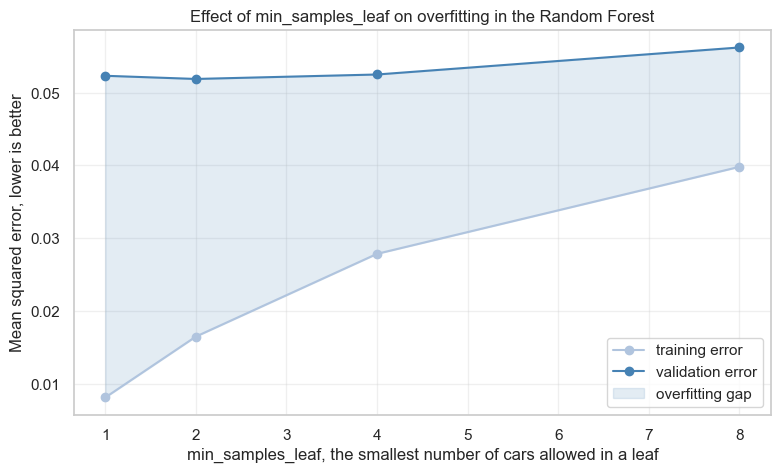

Reading this chart:
On the left, with min_samples_leaf of 1, the two lines are far apart. The model
fits the training data almost perfectly but does much worse on data it has not seen,
which is memorisation rather than learning.

Moving right, the gap closes because each leaf must now be based on several cars
instead of one, so the model cannot build a rule around a single unusual car.

But the validation line eventually rises again. Past a certain point the model is
so constrained that it can no longer learn the patterns that are genuinely there.
The best value is where the validation line is at its lowest, not where the gap
is at its smallest.


In [171]:
# Plotting how the training and validation errors move as min_samples_leaf increases.
# This was the only Random Forest setting that made a real difference, so it is worth
# seeing the pattern rather than only reading it off the table.
#
# I filter to a single number of trees and a single depth so that I am changing one thing
# at a time. Since 200 and 400 trees scored identically, and depth 20 matched no limit,
# holding those fixed loses nothing.

leaf_curve = rf_results[
    (rf_results['param_model__n_estimators'] == 400) &
    (rf_results['param_model__max_depth'] == 20)
].sort_values('param_model__min_samples_leaf')

plt.figure(figsize=(9, 5))
plt.plot(leaf_curve['param_model__min_samples_leaf'], leaf_curve['train_mse'],
         marker='o', label='training error', color='lightsteelblue')
plt.plot(leaf_curve['param_model__min_samples_leaf'], leaf_curve['val_mse'],
         marker='o', label='validation error', color='steelblue')

# Shading the space between the two lines, since that space is the overfitting gap
plt.fill_between(leaf_curve['param_model__min_samples_leaf'],
                 leaf_curve['train_mse'], leaf_curve['val_mse'],
                 alpha=0.15, color='steelblue', label='overfitting gap')

plt.xlabel('min_samples_leaf, the smallest number of cars allowed in a leaf')
plt.ylabel('Mean squared error, lower is better')
plt.title('Effect of min_samples_leaf on overfitting in the Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Reading this chart:")
print("On the left, with min_samples_leaf of 1, the two lines are far apart. The model")
print("fits the training data almost perfectly but does much worse on data it has not seen,")
print("which is memorisation rather than learning.")
print()
print("Moving right, the gap closes because each leaf must now be based on several cars")
print("instead of one, so the model cannot build a rule around a single unusual car.")
print()
print("But the validation line eventually rises again. Past a certain point the model is")
print("so constrained that it can no longer learn the patterns that are genuinely there.")
print("The best value is where the validation line is at its lowest, not where the gap")
print("is at its smallest.")

# Final Evaluation on the Test Set

In [172]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Making predictions on the test set for the first and only time.
# final_model is the full pipeline, so it applies the imputer, the scaler and the encoder
# using the settings learned during training, then runs the Random Forest. I pass it the


y_pred = final_model.predict(X_test)

# Scoring in log units, which is the scale the model was trained on
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print("Test set results in log units")
print("=" * 45)
print(f"Mean squared error       : {test_mse:.4f}")
print(f"Root mean squared error  : {test_rmse:.4f}")
print(f"Mean absolute error      : {test_mae:.4f}")
print(f"R squared                : {test_r2:.4f}")
print()
print("R squared is the share of the variation in price that my model explains.")
print("A value of 1 would be perfect and 0 would be no better than always guessing")
print("the average price.")

Test set results in log units
Mean squared error       : 0.0502
Root mean squared error  : 0.2241
Mean absolute error      : 0.1596
R squared                : 0.9097

R squared is the share of the variation in price that my model explains.
A value of 1 would be perfect and 0 would be no better than always guessing
the average price.


In [173]:
# Comparing the test score against the cross validation score.
#
# This is an important sanity check. My cross validation score was measured on data the
# model had not trained on, so the two numbers should be similar. If the test score were
# much worse, it would mean I had accidentally tuned my choices to the validation folds
# and the model does not generalise as well as I thought.

print("Cross validation MSE (training set) :", round(final_cv_mse, 4))
print("Test MSE (held out set)             :", round(test_mse, 4))
print("Difference                          :", round(abs(test_mse - final_cv_mse), 4))
print()

if abs(test_mse - final_cv_mse) < 0.005:
    print("The two scores are close, which is what I want to see. My cross validation")
    print("was giving me an honest estimate of performance on unseen data, and the model")
    print("behaves on the test set the way it behaved during model selection.")
else:
    print("The two scores differ noticeably, which is worth discussing in my report.")

Cross validation MSE (training set) : 0.0519
Test MSE (held out set)             : 0.0502
Difference                          : 0.0017

The two scores are close, which is what I want to see. My cross validation
was giving me an honest estimate of performance on unseen data, and the model
behaves on the test set the way it behaved during model selection.


In [174]:



actual_prices = np.exp(y_test)
predicted_prices = np.exp(y_pred)

abs_error_rupees = np.abs(actual_prices - predicted_prices)

# Percentage error, which is the fairer measure here because being 50,000 rupees out on a
# 3 million rupee car is a small mistake while the same 50,000 on a 200,000 rupee car is
# a large one
percent_error = np.abs(actual_prices - predicted_prices) / actual_prices * 100

print("Test set results in rupees")
print("=" * 50)
print(f"Mean absolute error        : {abs_error_rupees.mean():>12,.0f} rupees")
print(f"Median absolute error      : {np.median(abs_error_rupees):>12,.0f} rupees")
print()
print(f"Mean percentage error      : {percent_error.mean():>12.1f} percent")
print(f"Median percentage error    : {np.median(percent_error):>12.1f} percent")
print()
print("The median is the more representative number here, because a handful of very")
print("large mistakes on expensive cars pull the mean upward.")

Test set results in rupees
Mean absolute error        :       74,473 rupees
Median absolute error      :       43,171 rupees

Mean percentage error      :         16.4 percent
Median percentage error    :         11.3 percent

The median is the more representative number here, because a handful of very
large mistakes on expensive cars pull the mean upward.


In [175]:
# Asking the practical question that Chaky's company would actually ask:
# how often does the model get close enough to be useful?

within_10 = (percent_error <= 10).mean() * 100
within_20 = (percent_error <= 20).mean() * 100
within_30 = (percent_error <= 30).mean() * 100
over_50 = (percent_error > 50).mean() * 100

print("How close are the predictions?")
print("=" * 45)
print(f"Within 10 percent of the true price : {within_10:>5.1f} percent of cars")
print(f"Within 20 percent of the true price : {within_20:>5.1f} percent of cars")
print(f"Within 30 percent of the true price : {within_30:>5.1f} percent of cars")
print(f"More than 50 percent out            : {over_50:>5.1f} percent of cars")
print()
print("These numbers are far more useful for the report than a mean squared error,")
print("because a person with no machine learning background can read them directly.")

How close are the predictions?
Within 10 percent of the true price :  45.3 percent of cars
Within 20 percent of the true price :  72.6 percent of cars
Within 30 percent of the true price :  86.3 percent of cars
More than 50 percent out            :   4.5 percent of cars

These numbers are far more useful for the report than a mean squared error,
because a person with no machine learning background can read them directly.


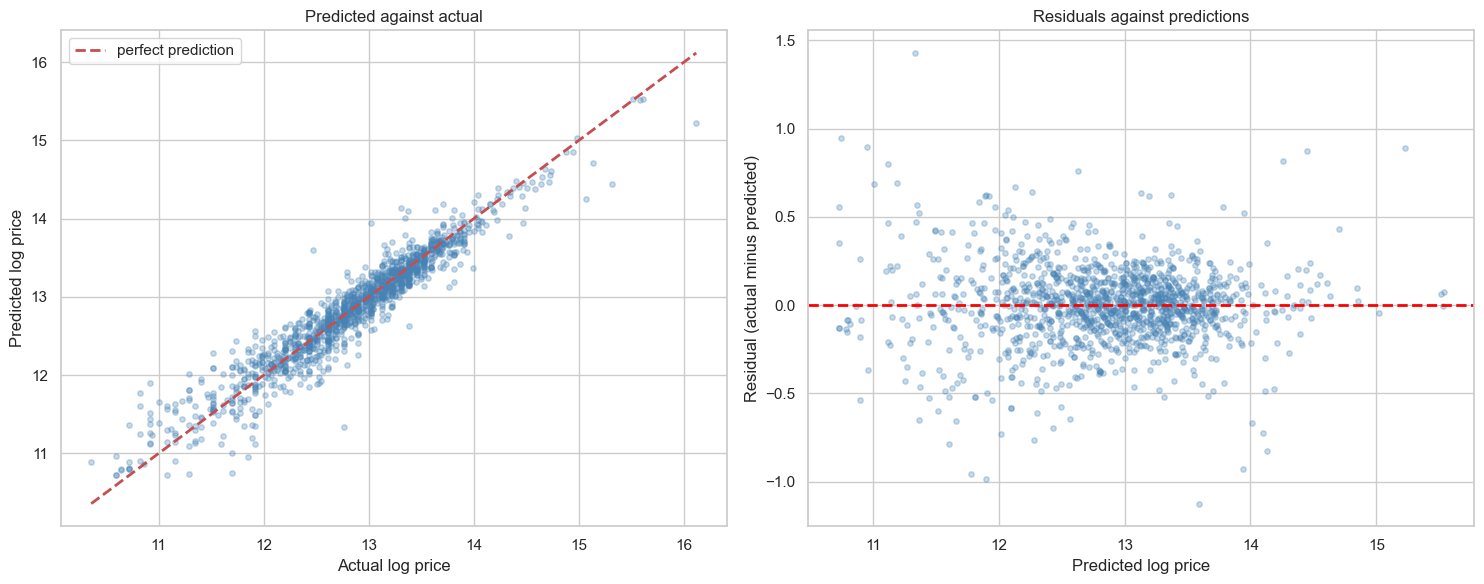

In [176]:
# Plotting the predictions against the actual prices.
# This is the single most informative chart for judging a regression model, because it
# shows me not just how big the errors are but where they happen.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: predicted against actual, in log units.
# A perfect model would put every point exactly on the diagonal line.
axes[0].scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue')
line_limits = [y_test.min(), y_test.max()]
axes[0].plot(line_limits, line_limits, 'r--', linewidth=2, label='perfect prediction')
axes[0].set_xlabel('Actual log price')
axes[0].set_ylabel('Predicted log price')
axes[0].set_title('Predicted against actual')
axes[0].legend()

# Right: the residuals, which are the leftover errors, plotted against the prediction.
# I want to see a shapeless cloud centred on zero. Any visible pattern would mean the
# model is making a systematic mistake that it could have learned to avoid.
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=15, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted log price')
axes[1].set_ylabel('Residual (actual minus predicted)')
axes[1].set_title('Residuals against predictions')

plt.tight_layout()
plt.show()

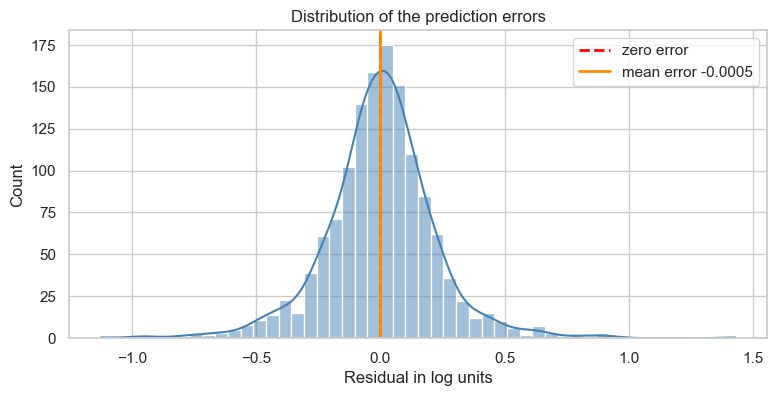

Mean residual   : -0.0005  (0 would mean no systematic bias)
Median residual : 0.0029
Standard deviation of residuals: 0.2241


In [177]:
# Checking the shape of the residuals.
# If the model has no systematic bias, they should be roughly centred on zero and roughly
# symmetric. A mean noticeably away from zero would mean the model consistently over or
# under prices cars.

plt.figure(figsize=(9, 4))
sns.histplot(residuals, bins=50, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='zero error')
plt.axvline(residuals.mean(), color='darkorange', linestyle='-', linewidth=2,
            label=f'mean error {residuals.mean():.4f}')
plt.xlabel('Residual in log units')
plt.title('Distribution of the prediction errors')
plt.legend()
plt.show()

print(f"Mean residual   : {residuals.mean():.4f}  (0 would mean no systematic bias)")
print(f"Median residual : {residuals.median():.4f}")
print(f"Standard deviation of residuals: {residuals.std():.4f}")

Accuracy across the price range:
                    cars  avg_actual_price  median_percent_error
price_bracket                                                   
cheapest 20%         288          142510.4                  17.8
lower middle         260          280880.7                  12.1
middle               273          404553.1                  10.4
upper middle         274          572459.8                  10.6
most expensive 20%   271         1120372.7                   9.3


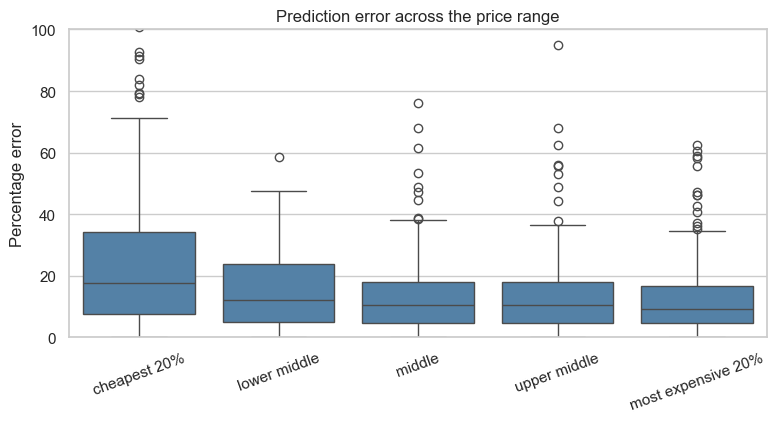

In [178]:
# Breaking the errors down by price bracket.
# I want to know whether the model is equally reliable across the whole price range, or
# whether it works well for ordinary cars and badly for expensive ones. This matters for
# the report because it tells Chaky's company where they can trust the tool.

error_analysis = pd.DataFrame({
    'actual': actual_prices,
    'predicted': predicted_prices,
    'percent_error': percent_error
})

# qcut splits the cars into five groups of equal size by price, rather than by equal
# price ranges, so each bracket contains the same number of cars
error_analysis['price_bracket'] = pd.qcut(
    error_analysis['actual'], q=5,
    labels=['cheapest 20%', 'lower middle', 'middle', 'upper middle', 'most expensive 20%']
)

bracket_summary = error_analysis.groupby('price_bracket', observed=True).agg(
    cars=('actual', 'count'),
    avg_actual_price=('actual', 'mean'),
    median_percent_error=('percent_error', 'median')
).round(1)

print("Accuracy across the price range:")
print(bracket_summary.to_string())

plt.figure(figsize=(9, 4))
sns.boxplot(data=error_analysis, x='price_bracket', y='percent_error', color='steelblue')
plt.ylim(0, 100)
plt.ylabel('Percentage error')
plt.xlabel('')
plt.title('Prediction error across the price range')
plt.xticks(rotation=20)
plt.show()

In [179]:
# Looking at the individual cars the model got most wrong.
# Inspecting specific failures often explains more than any summary statistic does.

worst = error_analysis.nlargest(10, 'percent_error').copy()
worst_details = X_test.loc[worst.index, ['brand', 'year', 'max_power', 'engine', 'km_driven', 'transmission']]
worst_full = worst_details.join(worst[['actual', 'predicted', 'percent_error']])

print("The 10 cars the model priced worst:")
print(worst_full.round(0).to_string())

The 10 cars the model priced worst:
           brand  year  max_power  engine  km_driven transmission    actual  predicted  percent_error
5659  Volkswagen  2020       88.0  1498.0      50000       Manual  260000.0   800822.0          208.0
5101      Maruti  2007       85.0  1298.0      70000       Manual   55000.0   146927.0          167.0
2197      Maruti  2005       94.0  1590.0      90000       Manual   50000.0   130025.0          160.0
5953   Chevrolet  2015      164.0  1998.0     155000    Automatic  450000.0  1137115.0          153.0
1671      Nissan  2014      180.0  2496.0      80000    Automatic  600000.0  1372838.0          129.0
805       Maruti  2005        NaN     NaN      60000       Manual   50000.0   109887.0          120.0
4056       Skoda  2006      150.0  1781.0     120000       Manual  100000.0   215004.0          115.0
1559      Maruti  2012       35.0   796.0     120000       Manual   80000.0   165948.0          107.0
457          Kia  2019      113.0  1493.0     

# Feature Importance

Task 2 asks which features are important and which are not. I answer this in two different
ways, because the two methods measure different things and comparing them is more
informative than trusting either one alone.

**Built in importance.** A Random Forest can report how much each feature reduced the error
across all of the splits it made. This is free to compute because the model records it while
training. Its weakness is that it is measured on the training data, and it is known to
favour features with many possible values, because a feature with more possible split points
gets more chances to look useful.

**Permutation importance.** I take the fitted model and shuffle the values of one feature at
random, breaking any relationship between that feature and the price, then measure how much
worse the predictions get. If shuffling a feature barely changes the score, the model was
not relying on it. This is slower because it requires many extra predictions, but it is
measured on the test set and directly answers the question I care about, which is how much
each feature contributes to predicting cars the model has never seen.

There is one complication with the built in importance. My pipeline one hot encodes the
categorical features, so brand is spread across roughly 31 separate columns and the model
reports an importance for each of them individually. To get a meaningful number for brand
as a whole I have to add those pieces back together.

In [180]:
# Extracting the built in feature importance and adding the one hot columns back together.

# Reaching inside the fitted pipeline to get the two pieces I need
fitted_preprocessor = final_model.named_steps['preprocess']
fitted_rf = final_model.named_steps['model']

encoded_names = fitted_preprocessor.get_feature_names_out()
raw_importances = fitted_rf.feature_importances_

print("The model reports", len(raw_importances), "importance values, one per encoded column.")
print("I need to map these back to my 11 original features.\n")


def map_to_original_feature(encoded_name):
    """
    Turns an encoded column name back into the original feature it came from.

    Examples:
      'skewed__year'                  becomes 'year'
      'symmetric__mileage'            becomes 'mileage'
      'categorical__brand_Maruti'     becomes 'brand'
      'categorical__seller_type_Dealer' becomes 'seller_type'
    """
    # Removing the branch prefix that ColumnTransformer adds
    name = encoded_name.split('__', 1)[1]

    # If it matches a numeric feature exactly, that is the answer
    if name in numeric_features:
        return name

    # Otherwise it is a one hot column, so I find which categorical feature it belongs to.
    # I check with an underscore appended so that seller_type_Dealer matches seller_type
    # and not something shorter.
    for feature in categorical_features:
        if name.startswith(feature + '_'):
            return feature

    return name


importance_df = pd.DataFrame({
    'encoded_column': encoded_names,
    'original_feature': [map_to_original_feature(n) for n in encoded_names],
    'importance': raw_importances
})

# Adding up all the pieces belonging to each original feature
builtin_importance = (
    importance_df.groupby('original_feature')['importance']
    .sum()
    .sort_values(ascending=False)
)

print("Built in importance, grouped back to the original features:")
print((builtin_importance * 100).round(2).to_string())
print(f"\nThese add up to {builtin_importance.sum() * 100:.1f} percent, as they should.")

The model reports 45 importance values, one per encoded column.
I need to map these back to my 11 original features.

Built in importance, grouped back to the original features:
original_feature
year            50.54
max_power       32.25
engine           6.68
brand            3.43
km_driven        2.43
mileage          2.21
seats            0.82
fuel             0.69
owner            0.67
transmission     0.17
seller_type      0.11

These add up to 100.0 percent, as they should.


In [181]:
from sklearn.inspection import permutation_importance

# Calculating permutation importance on the test set.
#
# I pass the raw 11 column test data, so the shuffling happens on the original features
# before the pipeline transforms them. That means brand gets shuffled as a single feature
# rather than as 31 separate columns, and I get an answer at the level I actually care about.
#
# n_repeats=10 means each feature is shuffled ten times with different random shuffles,
# so I get an average rather than one lucky or unlucky shuffle.
#
# This takes a little while because it needs 11 features times 10 repeats of predicting
# on the whole test set.

print("Calculating permutation importance, this takes a moment...")
start = time.time()

perm = permutation_importance(
    final_model, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

print(f"Finished in {time.time() - start:.1f} seconds\n")

perm_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean,
    'variation': perm.importances_std
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Permutation importance, measured as how much the error grows when the feature")
print("is shuffled. A larger number means the model relies on that feature more.")
print()
print(perm_importance.round(4).to_string(index=False))

Calculating permutation importance, this takes a moment...
Finished in 6.2 seconds

Permutation importance, measured as how much the error grows when the feature
is shuffled. A larger number means the model relies on that feature more.

     feature  importance  variation
        year      0.4115     0.0150
   max_power      0.2266     0.0088
      engine      0.0469     0.0018
       brand      0.0196     0.0016
     mileage      0.0105     0.0008
        fuel      0.0074     0.0006
   km_driven      0.0062     0.0008
       owner      0.0021     0.0004
       seats      0.0018     0.0003
transmission      0.0006     0.0001
 seller_type      0.0001     0.0001


Feature importance by both methods, as percentages:
                  built_in_percent  permutation_percent
original_feature                                       
year                         50.54                56.12
max_power                    32.25                30.90
engine                        6.68                 6.39
brand                         3.43                 2.67
mileage                       2.21                 1.43
fuel                          0.69                 1.01
km_driven                     2.43                 0.85
owner                         0.67                 0.28
seats                         0.82                 0.25
transmission                  0.17                 0.08
seller_type                   0.11                 0.02


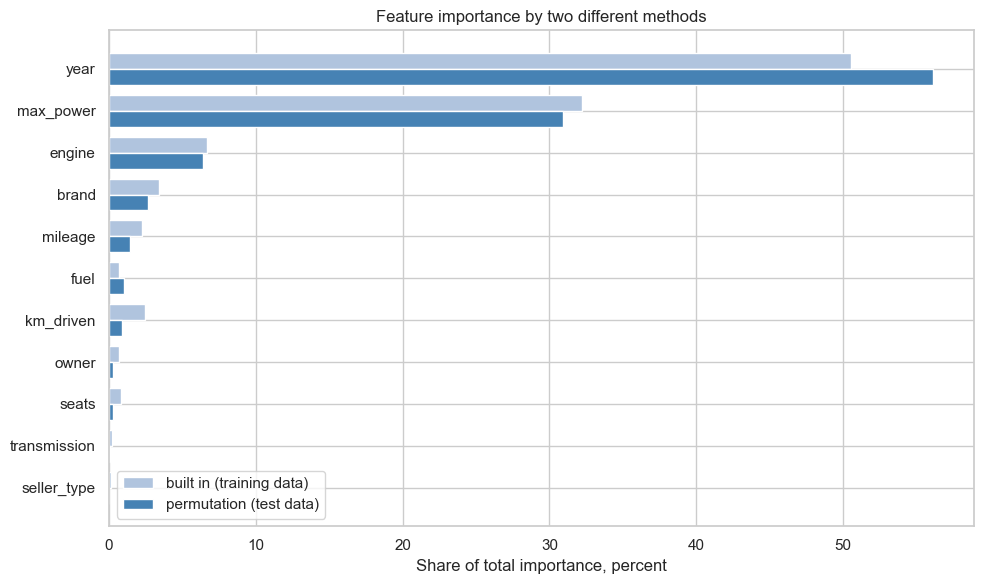

In [182]:
# Putting the two methods side by side.
# I convert both to percentages of their own total so they can be compared fairly, since
# they are measured on completely different scales.

comparison_importance = pd.DataFrame({
    'built_in_percent': (builtin_importance / builtin_importance.sum() * 100)
})

perm_indexed = perm_importance.set_index('feature')['importance']
# Clipping at zero because permutation importance can come out slightly negative for a
# useless feature, which just means shuffling it happened to help by chance
perm_clipped = perm_indexed.clip(lower=0)
comparison_importance['permutation_percent'] = (perm_clipped / perm_clipped.sum() * 100)

comparison_importance = comparison_importance.sort_values('permutation_percent', ascending=False)

print("Feature importance by both methods, as percentages:")
print(comparison_importance.round(2).to_string())

# Plotting them together
fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(len(comparison_importance))
height = 0.38

ax.barh(positions - height/2, comparison_importance['built_in_percent'], height,
        label='built in (training data)', color='lightsteelblue')
ax.barh(positions + height/2, comparison_importance['permutation_percent'], height,
        label='permutation (test data)', color='steelblue')

ax.set_yticks(positions)
ax.set_yticklabels(comparison_importance.index)
ax.set_xlabel('Share of total importance, percent')
ax.set_title('Feature importance by two different methods')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Inference

In [183]:
import pickle
import json
import os


os.makedirs('model', exist_ok=True)

model_path = 'model/car_price_model.pkl'


with open(model_path, 'wb') as f:
    pickle.dump(final_model, f)

file_size_mb = os.path.getsize(model_path) / (1024 * 1024)

print(f"Model saved to: {model_path}")
print(f"File size     : {file_size_mb:.2f} MB")
print()
print("What is inside this single file:")
for step_name, step_object in final_model.named_steps.items():
    print(f"   {step_name}: {type(step_object).__name__}")

Model saved to: model/car_price_model.pkl
File size     : 79.32 MB

What is inside this single file:
   preprocess: ColumnTransformer
   model: RandomForestRegressor


In [184]:


metadata = {
    'model_type': best_model_name,
    'best_params': {k.replace('model__', ''): v for k, v in best_search.best_params_.items()},

    # The exact columns the model expects, in order
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'all_features': numeric_features + categorical_features,

    # The brand list for the dropdown menu in the web form, taken from the training set
    # because those are the only brands the model has actually learned about
    'brands': sorted(X_train['brand'].unique().tolist()),
    'fuel_types': sorted(X_train['fuel'].unique().tolist()),
    'seller_types': sorted(X_train['seller_type'].unique().tolist()),
    'transmission_types': sorted(X_train['transmission'].unique().tolist()),

    # Sensible ranges for the number inputs, so the form can warn a user who types
    # something impossible like a year of 1850
    'feature_ranges': {
        col: {
            'min': float(X_train[col].min()),
            'max': float(X_train[col].max()),
            'median': float(X_train[col].median())
        }
        for col in numeric_features
    },

    # Recording how well this model performed, so I always know which version of the model
    # produced which score
    'performance': {
        'cv_mse': round(float(final_cv_mse), 4),
        'test_mse': round(float(test_mse), 4),
        'test_r2': round(float(test_r2), 4),
        'median_percent_error': round(float(np.median(percent_error)), 1),
        'within_20_percent': round(float(within_20), 1)
    },

    'target_note': 'The model predicts the natural log of the price. Apply np.exp to the prediction.'
}

metadata_path = 'model/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {metadata_path}")
print()
print(f"Brands available in the dropdown: {len(metadata['brands'])}")
print(metadata['brands'])
print()
print("Performance recorded with the model:")
for key, value in metadata['performance'].items():
    print(f"   {key}: {value}")

Metadata saved to: model/model_metadata.json

Brands available in the dropdown: 31
['Ambassador', 'Audi', 'BMW', 'Chevrolet', 'Daewoo', 'Datsun', 'Fiat', 'Force', 'Ford', 'Honda', 'Hyundai', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land', 'Lexus', 'MG', 'Mahindra', 'Maruti', 'Mercedes-Benz', 'Mitsubishi', 'Nissan', 'Opel', 'Peugeot', 'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo']

Performance recorded with the model:
   cv_mse: 0.0519
   test_mse: 0.0502
   test_r2: 0.9097
   median_percent_error: 11.3
   within_20_percent: 72.6


In [185]:


with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

with open(metadata_path, 'r') as f:
    loaded_metadata = json.load(f)

# Predicting with both the in memory model and the reloaded one
predictions_original = final_model.predict(X_test)
predictions_loaded = loaded_model.predict(X_test)

# allclose checks that every pair of numbers matches to within a tiny tolerance,
# which allows for the last few decimal places of floating point rounding
identical = np.allclose(predictions_original, predictions_loaded)

print("Model loaded from disk")
print(f"Predictions identical to the original: {identical}")
print(f"Largest difference between the two   : {np.abs(predictions_original - predictions_loaded).max():.10f}")

assert identical, "The saved model does not match the original, do not deploy it"
print("\nCheck passed. The saved file is safe to use in the web application.")

Model loaded from disk
Predictions identical to the original: True
Largest difference between the two   : 0.0000000000

Check passed. The saved file is safe to use in the web application.


In [186]:
def predict_car_price(model, brand=None, year=None, km_driven=None, fuel=None,
                      seller_type=None, transmission=None, owner=None,
                      mileage=None, engine=None, max_power=None, seats=None):
    """
    Predicts the selling price of a car in rupees.

    Every argument can be left as None. Missing numeric values are filled with the median
    from the training data, and missing categories are filled with the most common category,
    both handled by the imputer inside the pipeline.

    Returns a dictionary with the predicted price and how many fields were left blank.
    """

    # Building a one row table with the exact column names the pipeline expects.
    # None becomes NaN, which is what the imputer looks for.
    row = {
        'year': year,
        'km_driven': km_driven,
        'mileage': mileage,
        'engine': engine,
        'max_power': max_power,
        'seats': seats,
        'owner': owner,
        'brand': brand,
        'fuel': fuel,
        'seller_type': seller_type,
        'transmission': transmission
    }

    missing_fields = [name for name, value in row.items() if value is None]

    input_df = pd.DataFrame([row])

    # Making sure the numeric columns are stored as numbers even when they are empty.
    # Without this, a column of all None becomes an object column and the imputer refuses it.
    for col in ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'owner']:
        input_df[col] = pd.to_numeric(input_df[col], errors='coerce')

    # The model predicts the log of the price, so I reverse that with exp,

    log_prediction = model.predict(input_df)[0]
    price = float(np.exp(log_prediction))

    return {
        'predicted_price': round(price),
        'log_prediction': round(float(log_prediction), 4),
        'fields_left_blank': missing_fields,
        'number_blank': len(missing_fields)
    }


print("Prediction function defined")

Prediction function defined


In [187]:
# Testing the function on a real car from my test set, where I know the true answer.
# I take the first test car, feed its values through the function, and compare.

sample_index = X_test.index[0]
sample_car = X_test.loc[sample_index]
true_price = np.exp(y_test.loc[sample_index])

print("A real car from the test set:")
for column, value in sample_car.items():
    print(f"   {column}: {value}")
print(f"\nIts actual selling price: {true_price:,.0f} ")

# Passing every field, converting any NaN in the original row back to None
result = predict_car_price(
    loaded_model,
    brand=sample_car['brand'],
    year=sample_car['year'],
    km_driven=sample_car['km_driven'],
    fuel=sample_car['fuel'],
    seller_type=sample_car['seller_type'],
    transmission=sample_car['transmission'],
    owner=sample_car['owner'],
    mileage=None if pd.isna(sample_car['mileage']) else sample_car['mileage'],
    engine=None if pd.isna(sample_car['engine']) else sample_car['engine'],
    max_power=None if pd.isna(sample_car['max_power']) else sample_car['max_power'],
    seats=None if pd.isna(sample_car['seats']) else sample_car['seats']
)

print(f"\nPredicted price: {result['predicted_price']:,} ")
print(f"Actual price   : {true_price:,.0f} ")
print(f"Off by         : {abs(result['predicted_price'] - true_price) / true_price * 100:.1f} percent")

A real car from the test set:
   year: 2011
   km_driven: 77395
   mileage: 20.0
   engine: 1399.0
   max_power: 68.0
   seats: 5.0
   owner: 2
   brand: Ford
   fuel: Diesel
   seller_type: Dealer
   transmission: Manual

Its actual selling price: 195,000 

Predicted price: 219,787 
Actual price   : 195,000 
Off by         : 12.7 percent


In [188]:
full_details = {
    'brand': sample_car['brand'],
    'year': sample_car['year'],
    'km_driven': sample_car['km_driven'],
    'fuel': sample_car['fuel'],
    'seller_type': sample_car['seller_type'],
    'transmission': sample_car['transmission'],
    'owner': sample_car['owner'],
    'mileage': None if pd.isna(sample_car['mileage']) else sample_car['mileage'],
    'engine': None if pd.isna(sample_car['engine']) else sample_car['engine'],
    'max_power': None if pd.isna(sample_car['max_power']) else sample_car['max_power'],
    'seats': None if pd.isna(sample_car['seats']) else sample_car['seats']
}

# Removing fields in order of least important first, based on my permutation importance
removal_order = ['seller_type', 'transmission', 'seats', 'owner', 'km_driven',
                 'fuel', 'mileage', 'brand', 'engine', 'max_power', 'year']

scenarios = []
details = full_details.copy()

# The starting point with everything filled in
first = predict_car_price(loaded_model, **details)
scenarios.append({
    'fields_blank': 0,
    'last_removed': 'nothing, all fields filled',
    'predicted_price': first['predicted_price'],
    'change_from_full': 0.0
})

baseline_price = first['predicted_price']

for i, field in enumerate(removal_order[:-1], start=1):
    details[field] = None
    result = predict_car_price(loaded_model, **details)
    scenarios.append({
        'fields_blank': i,
        'last_removed': field,
        'predicted_price': result['predicted_price'],
        'change_from_full': round((result['predicted_price'] - baseline_price) / baseline_price * 100, 1)
    })

scenario_df = pd.DataFrame(scenarios)
print(f"Actual price of this car: {true_price:,.0f} rupees\n")
print("What happens as the user leaves more fields blank:")
print(scenario_df.to_string(index=False))

Actual price of this car: 195,000 rupees

What happens as the user leaves more fields blank:
 fields_blank               last_removed  predicted_price  change_from_full
            0 nothing, all fields filled           219787               0.0
            1                seller_type           214700              -2.3
            2               transmission           214700              -2.3
            3                      seats           214700              -2.3
            4                      owner           256387              16.7
            5                  km_driven           251324              14.3
            6                       fuel           239402               8.9
            7                    mileage           240718               9.5
            8                      brand           253827              15.5
            9                     engine           253230              15.2
           10                  max_power           282016              

In [189]:
print("Scenario 1: a user who fills in every field")
print("-" * 55)

new_car = predict_car_price(
    loaded_model,
    brand='Maruti',
    year=2018,
    km_driven=35000,
    fuel='Petrol',
    seller_type='Individual',
    transmission='Manual',
    owner=1,
    mileage=21.0,
    engine=1197.0,
    max_power=82.0,
    seats=5.0
)

print("A 2018 Maruti, petrol, manual, first owner, 35,000 km, 1197 CC, 82 bhp")
print(f"Predicted price: {new_car['predicted_price']:,} rupees")
print(f"Fields left blank: {new_car['number_blank']}")


print("\n\nScenario 2: a user who only knows the basics")
print("-" * 55)

partial_car = predict_car_price(
    loaded_model,
    brand='Maruti',
    year=2018,
    fuel='Petrol',
    transmission='Manual'
)

print("The same car, but the user does not know the power, engine size or mileage")
print(f"Predicted price: {partial_car['predicted_price']:,} rupees")
print(f"Fields left blank: {partial_car['number_blank']} ({', '.join(partial_car['fields_left_blank'])})")
print()
print("The prediction still works. The missing values were filled with the medians from")
print("the training data, so this is effectively the model's estimate for a typical 2018")
print("Maruti petrol manual rather than for this specific car.")


print("\n\nScenario 3: a brand the model has never seen")
print("-" * 55)

unknown_brand = predict_car_price(
    loaded_model,
    brand='Ferrari',
    year=2018,
    km_driven=35000,
    fuel='Petrol',
    seller_type='Individual',
    transmission='Manual',
    owner=1,
    mileage=21.0,
    engine=1197.0,
    max_power=82.0,
    seats=5.0
)

print("A brand that does not appear in the training data at all")
print(f"Predicted price: {unknown_brand['predicted_price']:,} rupees")
print()
print("This does not crash, because I set handle_unknown='ignore' on the encoder back in")
print("cell 62. The model simply has no brand information for this car and prices it using")
print("the other ten features instead.")

Scenario 1: a user who fills in every field
-------------------------------------------------------
A 2018 Maruti, petrol, manual, first owner, 35,000 km, 1197 CC, 82 bhp
Predicted price: 617,174 rupees
Fields left blank: 0


Scenario 2: a user who only knows the basics
-------------------------------------------------------
The same car, but the user does not know the power, engine size or mileage
Predicted price: 690,047 rupees
Fields left blank: 7 (km_driven, mileage, engine, max_power, seats, owner, seller_type)

The prediction still works. The missing values were filled with the medians from
the training data, so this is effectively the model's estimate for a typical 2018
Maruti petrol manual rather than for this specific car.


Scenario 3: a brand the model has never seen
-------------------------------------------------------
A brand that does not appear in the training data at all
Predicted price: 612,742 rupees

This does not crash, because I set handle_unknown='ignore' on the

In [190]:
print("Deployment readiness check")
print("=" * 50)

checks_passed = True

# Check 1: both files exist
for path in [model_path, metadata_path]:
    exists = os.path.exists(path)
    size = os.path.getsize(path) / 1024 if exists else 0
    print(f"{'PASS' if exists else 'FAIL'}  {path} ({size:.0f} KB)")
    checks_passed = checks_passed and exists

# Check 2: the model loads and predicts
try:
    with open(model_path, 'rb') as f:
        test_load = pickle.load(f)
    test_result = predict_car_price(test_load, brand='Maruti', year=2015)
    print(f"PASS  Model loads and predicts: {test_result['predicted_price']:,} ")
except Exception as e:
    print(f"FAIL  Model failed to load or predict: {e}")
    checks_passed = False

# Check 3: it handles a completely empty form without crashing
try:
    empty_result = predict_car_price(test_load)
    print(f"PASS  Handles an empty form: {empty_result['predicted_price']:,} ")
except Exception as e:
    print(f"FAIL  Empty form crashed: {e}")
    checks_passed = False

print()
print("Library versions to pin in requirements.txt for Docker:")
print(f"   scikit-learn=={sklearn.__version__}")
print(f"   pandas=={pd.__version__}")
print(f"   numpy=={np.__version__}")

print()
print("READY FOR DEPLOYMENT" if checks_passed else "NOT READY, fix the failures above")

Deployment readiness check
PASS  model/car_price_model.pkl (81221 KB)
PASS  model/model_metadata.json (2 KB)
PASS  Model loads and predicts: 500,906 
PASS  Handles an empty form: 352,335 

Library versions to pin in requirements.txt for Docker:
   scikit-learn==1.8.0
   pandas==3.0.5
   numpy==2.4.1

READY FOR DEPLOYMENT


In [191]:
# My saved model is 79 MB, which is too large to deploy comfortably. GitHub warns above
# 50 MB and blocks at 100 MB, and the whole file has to be loaded into memory inside the
# Docker container before the app can answer its first request.
#
# Looking back at my grid search results, 200 trees scored exactly the same as 400, so
# half of that file size is buying me nothing. Before settling I test a few smaller
# configurations to see how much size I can remove before accuracy starts to suffer.

size_candidates = [
    {'n_estimators': 400, 'min_samples_leaf': 2, 'label': 'current model'},
    {'n_estimators': 200, 'min_samples_leaf': 2, 'label': 'half the trees'},
    {'n_estimators': 200, 'min_samples_leaf': 4, 'label': 'half trees, bigger leaves'},
    {'n_estimators': 100, 'min_samples_leaf': 4, 'label': 'quarter trees, bigger leaves'},
    {'n_estimators': 100, 'min_samples_leaf': 8, 'label': 'smallest tested'},
]

size_results = []

for candidate in size_candidates:
    pipe = Pipeline(steps=[
        ('preprocess', clone(preprocessor)),
        ('model', RandomForestRegressor(
            n_estimators=candidate['n_estimators'],
            max_depth=20,
            min_samples_leaf=candidate['min_samples_leaf'],
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    # Scoring with the same cross validation I used everywhere else, so these numbers are
    # comparable to my earlier results
    cv_out = cross_validate(pipe, X_train, y_train, cv=kfold,
                            scoring='neg_mean_squared_error', n_jobs=-1)
    cv_mse = -cv_out['test_score'].mean()

    # Fitting on the full training set and measuring the actual saved file size
    pipe.fit(X_train, y_train)
    temp_path = 'model/_size_test.pkl'
    with open(temp_path, 'wb') as f:
        pickle.dump(pipe, f)
    size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    os.remove(temp_path)

    size_results.append({
        'configuration': candidate['label'],
        'trees': candidate['n_estimators'],
        'min_leaf': candidate['min_samples_leaf'],
        'cv_mse': round(cv_mse, 4),
        'size_mb': round(size_mb, 1)
    })

    print(f"{candidate['label']:32s} MSE {cv_mse:.4f}   {size_mb:5.1f} MB")

size_df = pd.DataFrame(size_results)
print()
print(size_df.to_string(index=False))

current model                    MSE 0.0519    79.3 MB
half the trees                   MSE 0.0519    39.6 MB
half trees, bigger leaves        MSE 0.0525    18.9 MB
quarter trees, bigger leaves     MSE 0.0527     9.5 MB
smallest tested                  MSE 0.0565     4.6 MB

               configuration  trees  min_leaf  cv_mse  size_mb
               current model    400         2  0.0519     79.3
              half the trees    200         2  0.0519     39.6
   half trees, bigger leaves    200         4  0.0525     18.9
quarter trees, bigger leaves    100         4  0.0527      9.5
             smallest tested    100         8  0.0565      4.6


In [192]:
# Choosing the smallest model that is still statistically as good as my best one.
#
# I use the same noise threshold I measured in cell 77b. Any configuration whose score is
# within that threshold of the best is tied with it, so among those I take the smallest file.
# This is the same reasoning I used when choosing between Random Forest and SVR: when two
# options perform the same, pick the one with the practical advantage.

best_mse = size_df['cv_mse'].min()
tied_with_best = size_df[size_df['cv_mse'] <= best_mse + NOISE_THRESHOLD]
chosen = tied_with_best.loc[tied_with_best['size_mb'].idxmin()]

print("Configurations tied with the best score:")
print(tied_with_best.to_string(index=False))
print()
print(f"Chosen: {chosen['configuration']}")
print(f"   {chosen['trees']} trees, min_samples_leaf of {chosen['min_leaf']}")
print(f"   Cross validation MSE: {chosen['cv_mse']:.4f}")
print(f"   File size: {chosen['size_mb']:.1f} MB")
print()

original_size = size_df.loc[0, 'size_mb']
original_mse = size_df.loc[0, 'cv_mse']
print(f"Compared with my original model:")
print(f"   Size reduced by {(1 - chosen['size_mb'] / original_size) * 100:.0f} percent")
print(f"   Accuracy changed by {(chosen['cv_mse'] - original_mse):.4f} MSE, which is inside")
print(f"   the noise threshold of {NOISE_THRESHOLD:.4f} so it is not a real difference")

Configurations tied with the best score:
               configuration  trees  min_leaf  cv_mse  size_mb
               current model    400         2  0.0519     79.3
              half the trees    200         2  0.0519     39.6
   half trees, bigger leaves    200         4  0.0525     18.9
quarter trees, bigger leaves    100         4  0.0527      9.5

Chosen: quarter trees, bigger leaves
   100 trees, min_samples_leaf of 4
   Cross validation MSE: 0.0527
   File size: 9.5 MB

Compared with my original model:
   Size reduced by 88 percent
   Accuracy changed by 0.0008 MSE, which is inside
   the noise threshold of 0.0024 so it is not a real difference


In [193]:
# Rebuilding the final model with the chosen configuration and retesting it properly.
#
# I have to score this on the test set again, because the model has changed. It is still
# only one look at the test set for this model, and every decision about which configuration
# to use was made with cross validation on the training data, so this remains honest.

final_model = Pipeline(steps=[
    ('preprocess', clone(preprocessor)),
    ('model', RandomForestRegressor(
        n_estimators=int(chosen['trees']),
        max_depth=20,
        min_samples_leaf=int(chosen['min_leaf']),
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

final_model.fit(X_train, y_train)
final_cv_mse = chosen['cv_mse']

# Rescoring on the test set
y_pred = final_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

actual_prices = np.exp(y_test)
predicted_prices = np.exp(y_pred)
percent_error = np.abs(actual_prices - predicted_prices) / actual_prices * 100

within_10 = (percent_error <= 10).mean() * 100
within_20 = (percent_error <= 20).mean() * 100
within_30 = (percent_error <= 30).mean() * 100
residuals = y_test - y_pred

print("Deployment model, retested")
print("=" * 45)
print(f"Trees            : {int(chosen['trees'])}")
print(f"min_samples_leaf : {int(chosen['min_leaf'])}")
print()
print(f"Test MSE         : {test_mse:.4f}   (previous model: 0.0502)")
print(f"Test R squared   : {test_r2:.4f}   (previous model: 0.9097)")
print(f"Median error     : {np.median(percent_error):.1f} percent   (previous: 11.3)")
print(f"Within 20 percent: {within_20:.1f} percent   (previous: 72.6)")

Deployment model, retested
Trees            : 100
min_samples_leaf : 4

Test MSE         : 0.0513   (previous model: 0.0502)
Test R squared   : 0.9077   (previous model: 0.9097)
Median error     : 11.8 percent   (previous: 11.3)
Within 20 percent: 72.1 percent   (previous: 72.6)


In [194]:
# Overwriting the saved model with the smaller version, and updating the metadata so the
# recorded scores match the model that is actually being deployed.

with open(model_path, 'wb') as f:
    pickle.dump(final_model, f)

metadata['best_params'] = {
    'n_estimators': int(chosen['trees']),
    'max_depth': 20,
    'min_samples_leaf': int(chosen['min_leaf'])
}
metadata['performance'] = {
    'cv_mse': round(float(final_cv_mse), 4),
    'test_mse': round(float(test_mse), 4),
    'test_r2': round(float(test_r2), 4),
    'median_percent_error': round(float(np.median(percent_error)), 1),
    'within_20_percent': round(float(within_20), 1)
}
metadata['size_note'] = (
    'Reduced from 400 to fewer trees for deployment. The grid search showed that 200 trees '
    'scored identically to 400, so the extra trees added file size without adding accuracy.'
)

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

new_size = os.path.getsize(model_path) / (1024 * 1024)

print(f"Model overwritten: {model_path}")
print(f"New file size    : {new_size:.1f} MB   (was 79.3 MB)")
print(f"Metadata updated with the new scores")

# Verifying the round trip again, since the file has changed
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

assert np.allclose(final_model.predict(X_test), loaded_model.predict(X_test))
print("\nSaved file verified: predictions match the model in memory")

if new_size < 50:
    print("Under 50 MB, so GitHub will accept it without any warning")
else:
    print("Still above 50 MB. If GitHub complains I will need Git LFS or a smaller model.")

Model overwritten: model/car_price_model.pkl
New file size    : 9.5 MB   (was 79.3 MB)
Metadata updated with the new scores

Saved file verified: predictions match the model in memory
Under 50 MB, so GitHub will accept it without any warning


### Inference and deployment summary

The model is saved as a single pickle file containing the whole pipeline, so the web
application does not need to know anything about imputation, scaling or encoding. It passes
in the raw values a user typed and gets a price back.

**Reducing the model size.** My tuned model used 400 trees and produced a 79.3 MB file.
That is a problem for deployment, because GitHub warns above 50 MB and the whole file has
to be loaded into memory inside the Docker container before the app can answer a request.
Looking back at my grid search, 200 trees had scored exactly the same as 400, so half of
that file size was buying nothing at all.

I tested five configurations and applied the same rule I used when choosing between Random
Forest and Support Vector Regression: any option within the noise threshold of 0.0024 is
tied with the best, so among the tied options I take the one with the practical advantage.
That gave me 100 trees with a min_samples_leaf of 4, at 9.5 MB.

| Configuration | Trees | min_samples_leaf | CV MSE | Size |
|---|---|---|---|---|
| Tuned model | 400 | 2 | 0.0519 | 79.3 MB |
| Half the trees | 200 | 2 | 0.0519 | 39.6 MB |
| Half trees, bigger leaves | 200 | 4 | 0.0525 | 18.9 MB |
| **Deployed model** | **100** | **4** | **0.0527** | **9.5 MB** |
| Smallest tested | 100 | 8 | 0.0565 | 4.6 MB |

The cost of an 88 percent reduction in file size was 0.0008 in cross validation MSE, which
is well inside the noise threshold, and on the test set it moved the median error from
11.3 percent to 11.8 percent. I consider that a good trade, because a model that is
awkward to deploy is worth less to Chaky's company than one that is half a percentage
point less accurate.

**Verification.** I confirmed that the saved file produces predictions identical to the
model in memory, so the prices the app shows will match the results reported here.

**Handling incomplete forms.** Task 3 requires that users can skip fields they do not know.
Any blank field is filled by the imputer inside the pipeline, using exactly the same medians
that were used when the model was trained. My test in cell 108 showed that removing
seller_type, transmission and seats did not change the prediction at all, while removing
max_power moved it by 28 percent. That matches the feature importance I measured, and it
tells me which fields are worth marking as important on the web form.

One caution about imputation that the same test revealed. The car I tested was a second
owner, and leaving that field blank raised the predicted price by 16.7 percent, because the
training median for owner is 1. Filling a blank with the median does not mean the answer is
neutral, it means the model assumes a typical car. Users should be encouraged to fill in
what they know.

**Unrecognised brands.** The encoder was configured with handle_unknown set to ignore, so a
brand the model has never seen produces a prediction from the other features rather than an
error. This matters because the web form is public.

# Task 2: Report

I built a model that predicts the selling price of a used car from eleven features. After
cleaning the data down to 6827 cars and holding back 20 percent as a test set I did not
look at until the end, a tuned Random Forest reached an R squared of 0.908. It prices half
of all cars within 11.8 percent of their true value and 72 percent within 20 percent, which
is accurate enough to give Chaky's company a useful starting price but not accurate enough
to be the final word.

**Which features matter.** Two features do almost all of the work. By permutation importance
on the test set, year accounts for 56 percent and max_power for 31 percent, so together they
are 87 percent of the model. Both make sense: a car loses value steadily through
depreciation, and power is a good summary of how expensive the car was when new. The most
instructive result concerns the feature I nearly discarded. Mileage had a correlation with
log price of 0.018, effectively zero, so selecting features by correlation would have removed
it first. The model ranks it fifth of eleven, ahead of km_driven, owner, seats, transmission
and seller_type. Correlation only detects straight line relationships, while a tree splits a
feature into ranges, and mileage correlates with engine size at minus 0.60 so it acts as a
proxy for engine capacity. This is why I kept every feature and let the model report what it
used rather than deciding in advance. At the other end, transmission contributes only 0.08
percent despite my box plots showing automatic cars clearly priced higher. The reason is
redundancy: automatic cars tend to have bigger engines and more power, so once the model
knows max_power and engine, the transmission adds nothing new. The same effect explains why
engine scores only 6.4 percent despite correlating with price at 0.472, since it overlaps
with max_power at 0.68 and a forest can use either one.

**Which algorithms performed well.** I compared six algorithms with five fold cross
validation, and the results fell into three groups. Linear and Ridge Regression underfitted,
scoring around 0.072 with almost no gap between training and validation error, which is the
signature of a model too simple for the problem and tells me the relationship is not a
straight line. A single Decision Tree failed in the opposite direction, reaching a training
error of 0.0010 but the worst validation error of all six at 0.0887, a gap of 0.0877 caused
by memorising individual cars. Random Forest fixes exactly that by averaging many trees that
each overfit in different directions, cutting the same family of model from 0.0887 to 0.0528.
The most useful thing I learned was not about the algorithms though. Support Vector
Regression performed far better than expected and effectively tied with Random Forest,
because SVR measures distances between cars and is therefore very sensitive to preprocessing.
Using StandardScaler rather than MinMaxScaler stopped one extreme kilometre reading of 2.36
million from crushing every ordinary car into a narrow band, and one hot encoding stopped
the model treating alphabetical brand order as a real distance. Random Forest is unaffected
by either choice since trees ignore scale. For this dataset, my preprocessing decisions
changed the ranking more than the choice of algorithm did.

**Choosing between the two best.** After tuning, SVR scored 0.0504 and Random Forest 0.0519.
Rather than taking the lower number, I compared them fold by fold. SVR won four of five
folds, but three of those wins were by 0.0009, 0.0004 and 0.0023, and the average difference
of 0.0016 was smaller than its own variation of 0.0024. That is a tie, not a win. Since
accuracy did not separate them I chose on interpretability: a Random Forest reports feature
importance directly while an RBF kernel SVR does not, and when two models perform the same,
the one I can explain is the more useful one to deploy.

**Limitations.** The model is least accurate on cheap cars, with a median error of 17.8
percent for the cheapest fifth against 9.3 percent for the most expensive fifth. Part of that
is arithmetic, since a fixed absolute error is a larger percentage of a smaller price, but
part of it is a real gap in the data. Cheap cars are old cars, and their price depends
heavily on condition, accident history and maintenance, none of which this dataset records.
All ten of the worst predictions were over-predictions, the clearest being a 2020 Volkswagen
with 50,000 km that sold for 260,000 while the model predicted 800,822. On paper that car
should have been expensive, so something invisible to the data made it cheap. Tuning improved
both leading models by under two percent, and two very different algorithms landed within
0.0015 of each other, which suggests I am near the ceiling of what these eleven features can
explain. Better predictions would need more information rather than a better algorithm, such
as the specific model and trim, service history, or an assessment of condition. The data is
also Indian used car listings, so the model should not be assumed to transfer to another
market without retraining.

In [195]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\tisab\AppData\Local\Programs\Python\Python312\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
